In [1]:
import re
from pathlib import Path
from collections import Counter

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import spacy
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Embedding,
    GRU,
    Input,
    LSTM,
    SimpleRNN
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from IPython.display import Markdown, display

In [2]:
# Q1. Corpus Acquisition and Cleaning

BOOKS = [
    {"id": 2701, "title": "Moby Dick; or, The Whale", "author": "Herman Melville"},
    {"id": 1342, "title": "Pride and Prejudice", "author": "Jane Austen"},
    {"id": 84, "title": "Frankenstein", "author": "Mary Shelley"},
    {"id": 1661, "title": "The Adventures of Sherlock Holmes", "author": "Arthur Conan Doyle"},
    {"id": 11, "title": "Alice's Adventures in Wonderland", "author": "Lewis Carroll"},
    {"id": 74, "title": "The Adventures of Tom Sawyer", "author": "Mark Twain"},
    {"id": 98, "title": "A Tale of Two Cities", "author": "Charles Dickens"},
    {"id": 1232, "title": "The Prince", "author": "Niccolo Machiavelli"},
    {"id": 5200, "title": "Metamorphosis", "author": "Franz Kafka"},
    {"id": 1952, "title": "The Yellow Wallpaper", "author": "Charlotte Perkins Gilman"},
]

BOOKS_DIR = Path("books")
BOOKS_DIR.mkdir(exist_ok=True)

cleaned_books = {}
summary_rows = []

def get_gutenberg_urls(book_id):
    return [
        f"https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}.txt",
    ]

def download_book(book_id, save_path):
    urls = get_gutenberg_urls(book_id)

    if save_path.exists():
        return {
            "status": "loaded from local cache",
            "source_url": urls[0],
            "http_status": "-",
        }

    for url in urls:
        try:
            response = requests.get(url, timeout=20)

            if response.status_code == 200 and len(response.content) > 1000:
                save_path.write_bytes(response.content)
                return {
                    "status": "downloaded by HTTP request",
                    "source_url": url,
                    "http_status": response.status_code,
                }

        except requests.RequestException:
            continue

    return {
        "status": "download failed",
        "source_url": "-",
        "http_status": "-",
    }


def read_text_file(path):
    encodings = ["utf-8", "utf-8-sig", "latin-1"]

    for encoding in encodings:
        try:
            return path.read_text(encoding=encoding), encoding
        except UnicodeDecodeError:
            continue

    return path.read_text(encoding="latin-1", errors="ignore"), "latin-1 with ignored errors"


def remove_gutenberg_boilerplate(text):
    start_pattern = r"\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*"

    start_match = re.search(start_pattern, text, flags=re.IGNORECASE | re.DOTALL)
    end_match = re.search(end_pattern, text, flags=re.IGNORECASE | re.DOTALL)

    cleaned = text

    if start_match:
        cleaned = cleaned[start_match.end():]

    end_match = re.search(end_pattern, cleaned, flags=re.IGNORECASE | re.DOTALL)
    if end_match:
        cleaned = cleaned[:end_match.start()]

    cleaned = cleaned.replace("\r\n", "\n").replace("\r", "\n")
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)
    cleaned = re.sub(r"[ \t]+", " ", cleaned)

    return cleaned.strip(), bool(start_match), bool(end_match)


def make_sample(text, length=250):
    sample = text[:length].replace("\n", " ")
    sample = re.sub(r"\s+", " ", sample)
    return sample.strip()


for book in BOOKS:
    book_id = book["id"]
    file_path = BOOKS_DIR / f"pg{book_id}.txt"

    download_info = download_book(book_id, file_path)

    if not file_path.exists():
        print(f"Book {book_id} could not be loaded.")
        continue

    raw_text, encoding_used = read_text_file(file_path)
    cleaned_text, start_removed, end_removed = remove_gutenberg_boilerplate(raw_text)

    cleaned_books[book_id] = {
        "title": book["title"],
        "author": book["author"],
        "text": cleaned_text,
    }

    summary_rows.append({
        "ID": book_id,
        "Title": book["title"],
        "Author": book["author"],
        "Status": download_info["status"],
        "HTTP status": download_info["http_status"],
        "Encoding": encoding_used,
        "Raw file size (KB)": round(file_path.stat().st_size / 1024, 2),
        "Raw characters": len(raw_text),
        "Cleaned characters": len(cleaned_text),
        "Cleaned words": len(cleaned_text.split()),
        "Start marker removed": start_removed,
        "End marker removed": end_removed,
        "Source URL": download_info["source_url"],
        "Sample cleaned text": make_sample(cleaned_text),
    })


summary_df = pd.DataFrame(summary_rows)

display(Markdown("### Q1 completed"))
print(f"Number of loaded books: {len(cleaned_books)} / {len(BOOKS)}")

display(summary_df.drop(columns=["Sample cleaned text"]))

display(Markdown("### Sample cleaned text from each book"))
display(summary_df[["ID", "Title", "Sample cleaned text"]])

### Q1 completed

Number of loaded books: 10 / 10


,ID,Title,Author,Status,HTTP status,Encoding,Raw file size (KB),Raw characters,Cleaned characters,Cleaned words,Start marker removed,End marker removed,Source URL
0,2701,"Moby Dick; or, The Whale",Herman Melville,loaded from local cache,-,utf-8,1246.35,1238280,1218168,212796,True,True,https://www.gutenberg.org/files/2701/2701-0.txt
1,1342,Pride and Prejudice,Jane Austen,loaded from local cache,-,utf-8,754.29,748168,721387,127359,True,True,https://www.gutenberg.org/files/1342/1342-0.txt
2,84,Frankenstein,Mary Shelley,loaded from local cache,-,utf-8,438.37,438842,419141,75042,True,True,https://www.gutenberg.org/files/84/84-0.txt
3,1661,The Adventures of Sherlock Holmes,Arthur Conan Doyle,loaded from local cache,-,utf-8,593.37,581602,561851,104506,True,True,https://www.gutenberg.org/files/1661/1661-0.txt
4,11,Alice's Adventures in Wonderland,Lewis Carroll,loaded from local cache,-,utf-8,170.23,163951,144013,26525,True,True,https://www.gutenberg.org/files/11/11-0.txt
5,74,The Adventures of Tom Sawyer,Mark Twain,loaded from local cache,-,utf-8,424.18,412089,392395,70800,True,True,https://www.gutenberg.org/files/74/74-0.txt
6,98,A Tale of Two Cities,Charles Dickens,loaded from local cache,-,utf-8,788.28,776913,756960,135886,True,True,https://www.gutenberg.org/files/98/98-0.txt
7,1232,The Prince,Niccolo Machiavelli,loaded from local cache,-,utf-8,300.81,301949,282480,49943,True,True,https://www.gutenberg.org/files/1232/1232-0.txt
8,5200,Metamorphosis,Franz Kafka,loaded from local cache,-,utf-8,138.68,138295,118465,21943,True,True,https://www.gutenberg.org/files/5200/5200-0.txt
9,1952,The Yellow Wallpaper,Charlotte Perkins Gilman,loaded from local cache,-,utf-8,51.34,50832,31496,6085,True,True,https://www.gutenberg.org/files/1952/1952-0.txt


### Sample cleaned text from each book

,ID,Title,Sample cleaned text
0,2701,"Moby Dick; or, The Whale","MOBY-DICK; or, THE WHALE. By Herman Melville C..."
1,1342,Pride and Prejudice,[Illustration: GEORGE ALLEN PUBLISHER 156 CHAR...
2,84,Frankenstein,"Frankenstein; or, the Modern Prometheus by Mar..."
3,1661,The Adventures of Sherlock Holmes,The Adventures of Sherlock Holmes by Arthur Co...
4,11,Alice's Adventures in Wonderland,[Illustration] Alice’s Adventures in Wonderlan...
5,74,The Adventures of Tom Sawyer,THE ADVENTURES OF TOM SAWYER By Mark Twain (Sa...
6,98,A Tale of Two Cities,A TALE OF TWO CITIES A STORY OF THE FRENCH REV...
7,1232,The Prince,The Prince by Nicolo Machiavelli Translated by...
8,5200,Metamorphosis,Metamorphosis by Franz Kafka Translated by Dav...
9,1952,The Yellow Wallpaper,The Yellow Wallpaper By Charlotte Perkins Gilm...


### Q2 Summary

,ID,Title,Words after normalization,-ing words,Unique words,Contractions normalized,Special characters removed,love count,death count,time count,man count
0,2701,"Moby Dick; or, The Whale",218057,7203,17131,877,45161,24,90,334,530
1,1342,Pride and Prejudice,128037,3407,6832,18,26740,102,9,201,158
2,84,Frankenstein,75312,1444,7013,1,10714,59,79,98,137
3,1661,The Adventures of Sherlock Holmes,105676,2505,7874,222,22711,18,31,151,305
4,11,Alice's Adventures in Wonderland,27333,919,2564,517,8002,3,1,71,5
5,74,The Adventures of Tom Sawyer,73884,1993,7281,1483,16868,11,16,191,61
6,98,A Tale of Two Cities,137896,3850,9689,380,32404,56,67,267,300
7,1232,The Prince,50126,1179,5215,0,6887,7,36,96,81
8,5200,Metamorphosis,22236,708,2565,167,2869,2,3,59,7
9,1952,The Yellow Wallpaper,6241,153,1208,73,977,0,0,11,2


### Keyword-specific sentence examples

,Keyword,Book,Sentence example
0,love,"Moby Dick; or, The Whale","“She came to bespeak a monument for her first love, who had been killed by a whale in the Pacific ocean, no less than forty years ago.” —_Ibid_."
1,love,"Moby Dick; or, The Whale","I love to sail forbidden seas, and land on barbarous coasts."
2,death,"Moby Dick; or, The Whale","“Soon to the sport of death the crews repair: Rodmond unerring o’er his head suspends The barbed steel, and every turn attends.” —_Falconer’s Shipwreck_."
3,death,"Moby Dick; or, The Whale","You shuddered as you gazed, and wondered what monstrous cannibal and savage could ever have gone a death-harvesting with such a hacking, horrifying implement."
4,time,"Moby Dick; or, The Whale","Being once pursued by a whale which he had wounded, he parried the assault for some time with a lance; but the furious monster at length rushed on the boat; himself and comrades only being preserved by leaping into the water when they saw the onset was inevita..."
5,time,"Moby Dick; or, The Whale","If they but knew it, almost all men in their degree, some time or other, cherish very nearly the same feelings towards the ocean with me."
6,man,"Moby Dick; or, The Whale","“By art is created that great Leviathan, called a Commonwealth or State—(in Latin, Civitas) which is but an artificial man.” —_Opening sentence of Hobbes’s Leviathan_."
7,man,"Moby Dick; or, The Whale","“Myself have agreed to try whether I can master and kill this Sperma-ceti whale, for I could never hear of any of that sort that was killed by any man, such is his fierceness and swiftness.” —_Richard Strafford’s Letter from the Bermudas."
8,love,Pride and Prejudice,"There is much more difference as to their best work than in the case of those others who are loved “by allowance” by convention, and because it is felt to be the right and proper thing to love them."
9,love,Pride and Prejudice,"It has sometimes, I believe, been urged that his pride is unnatural at first in its expression and later in its yielding, while his falling in love at all is not extremely probable."


### Top 20 normalized words

,Word,Frequency
0,the,46858
1,and,28018
2,of,23989
3,to,22759
4,a,17462
5,in,14382
6,i,14320
7,that,11973
8,it,11487
9,he,10148


### Top 20 words ending with -ing

,-ing word,Frequency
0,being,902
1,nothing,740
2,thing,484
3,having,465
4,something,464
5,morning,421
6,going,392
7,looking,372
8,anything,347
9,king,266


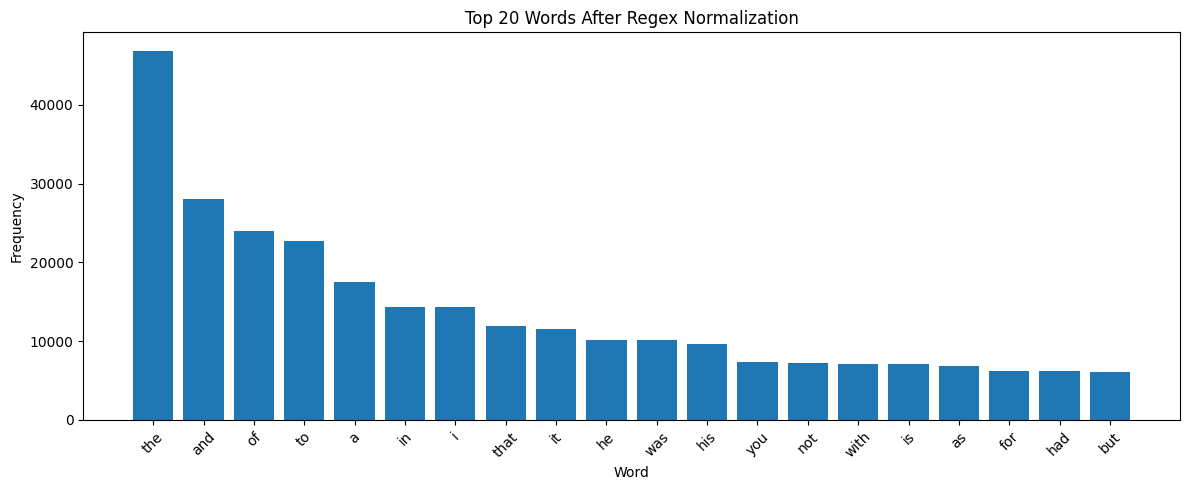

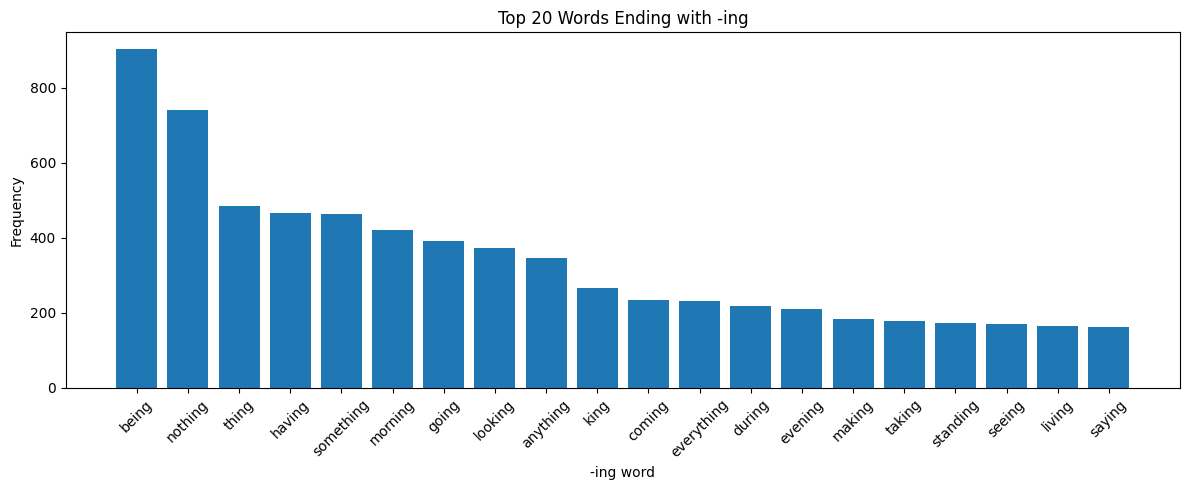

The most frequent normalized words are mostly function words. This is expected in Q2 because stopword filtering is performed later in Q3.

Q2 completed
Normalized book texts saved to folder: normalized_books


In [3]:
# Q2. Regular Expression-Based Text Normalization

CONTRACTION_PATTERNS = [
    (r"\bain't\b", "is not"),
    (r"\bcan['’]t\b", "cannot"),
    (r"\bwon['’]t\b", "will not"),
    (r"\bshan['’]t\b", "shall not"),
    (r"\blet['’]s\b", "let us"),

    (r"\bi['’]m\b", "i am"),
    (r"\bit['’]s\b", "it is"),
    (r"\bhe['’]s\b", "he is"),
    (r"\bshe['’]s\b", "she is"),
    (r"\bthat['’]s\b", "that is"),
    (r"\bwhat['’]s\b", "what is"),
    (r"\bthere['’]s\b", "there is"),

    (r"\bi['’]ve\b", "i have"),
    (r"\bwe['’]ve\b", "we have"),
    (r"\bthey['’]ve\b", "they have"),
    (r"\byou['’]ve\b", "you have"),

    (r"\bi['’]ll\b", "i will"),
    (r"\byou['’]ll\b", "you will"),
    (r"\bhe['’]ll\b", "he will"),
    (r"\bshe['’]ll\b", "she will"),
    (r"\bwe['’]ll\b", "we will"),
    (r"\bthey['’]ll\b", "they will"),

    (r"\bi['’]d\b", "i would"),
    (r"\byou['’]d\b", "you would"),
    (r"\bhe['’]d\b", "he would"),
    (r"\bshe['’]d\b", "she would"),
    (r"\bwe['’]d\b", "we would"),
    (r"\bthey['’]d\b", "they would"),

    (r"\b([a-z]+)n['’]t\b", r"\1 not"),
]


def standardize_apostrophes(text):
    return (
        text.replace("’", "'")
            .replace("‘", "'")
            .replace("“", '"')
            .replace("”", '"')
    )


def normalize_contractions(text):
    text = standardize_apostrophes(text.lower())

    total_replacements = 0

    for pattern, replacement in CONTRACTION_PATTERNS:
        text, count = re.subn(pattern, replacement, text)
        total_replacements += count

    return text, total_replacements


def clean_text_regex(text):
    text, contractions_replaced = normalize_contractions(text)

    special_characters_removed = len(re.findall(r"[^a-zA-Z0-9\s]", text))

    text = re.sub(r"\b([a-z]+)'s\b", r"\1", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip(), contractions_replaced, special_characters_removed


def clean_sentence_for_display(sentence, max_length=260):
    sentence = re.sub(r"\s+", " ", sentence).strip()

    if len(sentence) > max_length:
        sentence = sentence[:max_length].rstrip() + "..."

    return sentence


def extract_keyword_sentences(text, keyword, max_sentences=2):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    keyword_pattern = re.compile(rf"\b{re.escape(keyword)}\b", flags=re.IGNORECASE)

    excluded_front_matter = re.compile(
        r"\b(contents|chapter|illustration|preface|tail piece)\b",
        flags=re.IGNORECASE
    )

    matched_sentences = []

    for sentence in sentences:
        sentence_clean = clean_sentence_for_display(sentence)

        if not keyword_pattern.search(sentence_clean):
            continue

        if excluded_front_matter.search(sentence_clean):
            continue

        if len(sentence_clean.split()) < 8:
            continue

        matched_sentences.append(sentence_clean)

    return matched_sentences[:max_sentences]


normalized_books = {}
q2_summary_rows = []
keyword_sentence_rows = []

all_words = []
all_ing_words = []

keywords = ["love", "death", "time", "man"]

for book_id, data in cleaned_books.items():
    title = data["title"]
    raw_text = data["text"]

    normalized_text, contractions_replaced, special_characters_removed = clean_text_regex(raw_text)
    words = normalized_text.split()

    ing_words = re.findall(r"\b[a-z]+ing\b", normalized_text)

    normalized_books[book_id] = {
        "title": title,
        "author": data["author"],
        "text": normalized_text,
        "words": words,
        "ing_words": ing_words,
    }

    all_words.extend(words)
    all_ing_words.extend(ing_words)

    row = {
        "ID": book_id,
        "Title": title,
        "Words after normalization": len(words),
        "-ing words": len(ing_words),
        "Unique words": len(set(words)),
        "Contractions normalized": contractions_replaced,
        "Special characters removed": special_characters_removed,
    }

    for keyword in keywords:
        keyword_count = len(re.findall(rf"\b{re.escape(keyword)}\b", normalized_text))
        row[f"{keyword} count"] = keyword_count

        examples = extract_keyword_sentences(raw_text, keyword, max_sentences=2)

        for sentence in examples:
            keyword_sentence_rows.append({
                "Keyword": keyword,
                "Book": title,
                "Sentence example": sentence,
            })

    q2_summary_rows.append(row)


q2_summary_df = pd.DataFrame(q2_summary_rows)
keyword_sentences_df = pd.DataFrame(keyword_sentence_rows)

display(Markdown("### Q2 Summary"))
display(q2_summary_df)

display(Markdown("### Keyword-specific sentence examples"))

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", None
):
    display(
        keyword_sentences_df.style.set_properties(
            subset=["Sentence example"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "900px",
            }
        )
    )


word_freq = Counter(all_words)
ing_word_freq = Counter(all_ing_words)

top_words_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

top_ing_words_df = pd.DataFrame(
    ing_word_freq.most_common(20),
    columns=["-ing word", "Frequency"]
)

display(Markdown("### Top 20 normalized words"))
display(top_words_df)

display(Markdown("### Top 20 words ending with -ing"))
display(top_ing_words_df)


plt.figure(figsize=(12, 5))
plt.bar(top_words_df["Word"], top_words_df["Frequency"])
plt.title("Top 20 Words After Regex Normalization")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
plt.bar(top_ing_words_df["-ing word"], top_ing_words_df["Frequency"])
plt.title("Top 20 Words Ending with -ing")
plt.xlabel("-ing word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NORMALIZED_DIR = Path("normalized_books")
NORMALIZED_DIR.mkdir(exist_ok=True)

for book_id, data in normalized_books.items():
    output_path = NORMALIZED_DIR / f"normalized_pg{book_id}.txt"
    output_path.write_text(data["text"], encoding="utf-8")

display(Markdown(
    "The most frequent normalized words are mostly function words. "
    "This is expected in Q2 because stopword filtering is performed later in Q3."
))

print("Q2 completed")
print("Normalized book texts saved to folder:", NORMALIZED_DIR)

### Q3 Summary

,ID,Title,NLTK word tokens,spaCy word tokens,Word token difference,NLTK sentences,spaCy sentences,Sentence difference,Tokens after stopword filtering,Unique filtered tokens
0,2701,"Moby Dick; or, The Whale",258699,260546,1847,9064,9418,354,105036,16326
1,1342,Pride and Prejudice,151020,152543,1523,4795,5754,959,55252,6460
2,84,Frankenstein,85539,85881,342,3075,3249,174,34130,6764
3,1661,The Adventures of Sherlock Holmes,125463,127667,2204,4716,5799,1083,44189,7383
4,11,Alice's Adventures in Wonderland,35021,35157,136,984,1378,394,11847,2342
5,74,The Adventures of Tom Sawyer,90483,89982,-501,3666,4365,699,33545,6951
6,98,A Tale of Two Cities,166840,168428,1588,5622,6696,1074,61343,9383
7,1232,The Prince,56762,56843,81,1285,1337,52,22250,4928
8,5200,Metamorphosis,25292,25031,-261,731,772,41,9914,2425
9,1952,The Yellow Wallpaper,7247,7181,-66,376,392,16,2596,1074


### Tokenisation behaviour examples

,ID,Title,NLTK first 25 tokens,spaCy first 25 tokens
0,2701,"Moby Dick; or, The Whale","MOBY-DICK | ; | or | , | THE | WHALE | . | By | Herman | Melville | CONTENTS | ETYMOLOGY | . | EXTRACTS | ( | Supplied | by | a | Sub-Sub-Librarian | ) | . | CHAPTER | 1 | . | Loomings","MOBY | - | DICK | ; | or | , | THE | WHALE | . | By | Herman | Melville | CONTENTS | ETYMOLOGY | . | EXTRACTS | ( | Supplied | by | a | Sub | - | Sub | - | Librarian"
1,1342,Pride and Prejudice,[ | Illustration | : | GEORGE | ALLEN | PUBLISHER | 156 | CHARING | CROSS | ROAD | LONDON | RUSKIN | HOUSE | ] | [ | Illustration | : | _Reading | Jane | ’ | s | Letters._ | _Chap | 34._ | ],[ | Illustration | : | GEORGE | ALLEN | PUBLISHER | 156 | CHARING | CROSS | ROAD | LONDON | RUSKIN | HOUSE | ] | [ | Illustration | : | _ | Reading | Jane | ’s | Letters | . | _ | _
2,84,Frankenstein,"Frankenstein | ; | or | , | the | Modern | Prometheus | by | Mary | Wollstonecraft | ( | Godwin | ) | Shelley | CONTENTS | Letter | 1 | Letter | 2 | Letter | 3 | Letter | 4 | Chapter | 1","Frankenstein | ; | or | , | the | Modern | Prometheus | by | Mary | Wollstonecraft | ( | Godwin | ) | Shelley | CONTENTS | Letter | 1 | Letter | 2 | Letter | 3 | Letter | 4 | Chapter | 1"
3,1661,The Adventures of Sherlock Holmes,The | Adventures | of | Sherlock | Holmes | by | Arthur | Conan | Doyle | Contents | I | . | A | Scandal | in | Bohemia | II | . | The | Red-Headed | League | III | . | A | Case,The | Adventures | of | Sherlock | Holmes | by | Arthur | Conan | Doyle | Contents | I. | A | Scandal | in | Bohemia | II | . | The | Red | - | Headed | League | III | . | A
4,11,Alice's Adventures in Wonderland,[ | Illustration | ] | Alice | ’ | s | Adventures | in | Wonderland | by | Lewis | Carroll | THE | MILLENNIUM | FULCRUM | EDITION | 3.0 | Contents | CHAPTER | I | . | Down | the | Rabbit-Hole | CHAPTER,[ | Illustration | ] | Alice | ’s | Adventures | in | Wonderland | by | Lewis | Carroll | THE | MILLENNIUM | FULCRUM | EDITION | 3.0 | Contents | CHAPTER | I. | Down | the | Rabbit | - | Hole | CHAPTER
5,74,The Adventures of Tom Sawyer,THE | ADVENTURES | OF | TOM | SAWYER | By | Mark | Twain | ( | Samuel | Langhorne | Clemens | ) | CONTENTS | CHAPTER | I. | Y-o-u-u | Tom | — | Aunt | Polly | Decides | Upon | her | Duty,THE | ADVENTURES | OF | TOM | SAWYER | By | Mark | Twain | ( | Samuel | Langhorne | Clemens | ) | CONTENTS | CHAPTER | I. | Y | - | o | - | u | - | u | Tom | —
6,98,A Tale of Two Cities,A | TALE | OF | TWO | CITIES | A | STORY | OF | THE | FRENCH | REVOLUTION | By | Charles | Dickens | CONTENTS | Book | the | First | -- | Recalled | to | Life | CHAPTER | I | The,A | TALE | OF | TWO | CITIES | A | STORY | OF | THE | FRENCH | REVOLUTION | By | Charles | Dickens | CONTENTS | Book | the | First | -- | Recalled | to | Life | CHAPTER | I | The
7,1232,The Prince,The | Prince | by | Nicolo | Machiavelli | Translated | by | W. | K. | Marriott | Contents | INTRODUCTION | YOUTH | Æt | . | 1-25 | — | 1469-94 | OFFICE | Æt | . | 25-43 | — | 1494-1512 | LITERATURE,The | Prince | by | Nicolo | Machiavelli | Translated | by | W. | K. | Marriott | Contents | INTRODUCTION | YOUTH | Æt | . | 1 | - | 25—1469 | - | 94 | OFFICE | Æt | . | 25 | -
8,5200,Metamorphosis,"Metamorphosis | by | Franz | Kafka | Translated | by | David | Wyllie | I | One | morning | , | when | Gregor | Samsa | woke | from | troubled | dreams | , | he | found | himself | transformed | in","Metamorphosis | by | Franz | Kafka | Translated | by | David | Wyllie | I | One | morning | , | when | Gregor | Samsa | woke | from | troubled | dreams | , | he | found | himself | transformed | in"
9,1952,The Yellow Wallpaper,The | Yellow | Wallpaper | By | Charlotte | Perkins | Gilman | It | is | very | seldom | that | mere | ordinary | people | like | John | and | myself | secure | ancestral | halls | for | the | summer,The | Yellow | Wallpaper | By | Charlotte | Perkins | Gilman | It | is | very | seldom | that | mere | ordinary | peopl

NLTK and spaCy produce different token counts because they handle punctuation, hyphenated words, contractions, abbreviations, and sentence boundaries differently. For example, spaCy often splits hyphenated expressions into separate tokens, while NLTK may keep some of them as one token.

### Top 25 tokens after stopword filtering

,Token,Frequency
0,said,2908
1,one,2886
2,would,2457
3,could,1964
4,upon,1747
5,man,1518
6,time,1440
7,little,1401
8,like,1311
9,see,1178


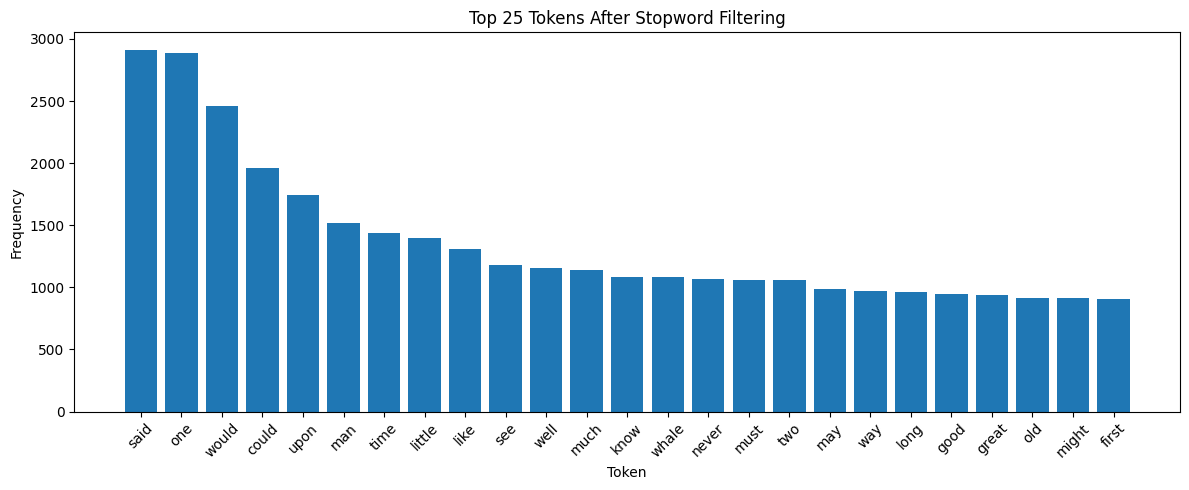

Q3 completed
Filtered token files saved to folder: filtered_tokens


In [4]:
# Q3. Tokenisation and Stopword Filtering

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

nlp_q3 = spacy.load("en_core_web_sm", disable=["ner"])
nlp_q3.max_length = max(len(data["text"]) for data in cleaned_books.values()) + 100

english_stopwords = set(stopwords.words("english"))

q3_summary_rows = []
tokenisation_example_rows = []
all_filtered_tokens = []
filtered_tokens_by_book = {}


def tokenize_with_nltk(text):
    word_tokens = word_tokenize(text)
    sentence_tokens = sent_tokenize(text)
    return word_tokens, sentence_tokens


def tokenize_with_spacy(text):
    doc = nlp_q3(text)

    word_tokens = [
        token.text
        for token in doc
        if not token.is_space
    ]

    sentence_tokens = [
        sent.text.strip()
        for sent in doc.sents
        if sent.text.strip()
    ]

    return word_tokens, sentence_tokens


def remove_stopwords_and_non_words(tokens):
    filtered_tokens = []

    for token in tokens:
        token = token.lower()

        if not re.fullmatch(r"[a-z]+", token):
            continue

        if token in english_stopwords:
            continue

        filtered_tokens.append(token)

    return filtered_tokens


def format_token_list(tokens, max_tokens=25):
    return " | ".join(tokens[:max_tokens])


for book_id, data in cleaned_books.items():
    title = data["title"]
    text = data["text"]

    nltk_words, nltk_sentences = tokenize_with_nltk(text)
    spacy_words, spacy_sentences = tokenize_with_spacy(text)

    filtered_tokens = remove_stopwords_and_non_words(nltk_words)

    all_filtered_tokens.extend(filtered_tokens)
    filtered_tokens_by_book[book_id] = filtered_tokens

    q3_summary_rows.append({
        "ID": book_id,
        "Title": title,
        "NLTK word tokens": len(nltk_words),
        "spaCy word tokens": len(spacy_words),
        "Word token difference": len(spacy_words) - len(nltk_words),
        "NLTK sentences": len(nltk_sentences),
        "spaCy sentences": len(spacy_sentences),
        "Sentence difference": len(spacy_sentences) - len(nltk_sentences),
        "Tokens after stopword filtering": len(filtered_tokens),
        "Unique filtered tokens": len(set(filtered_tokens)),
    })

    tokenisation_example_rows.append({
        "ID": book_id,
        "Title": title,
        "NLTK first 25 tokens": format_token_list(nltk_words),
        "spaCy first 25 tokens": format_token_list(spacy_words),
    })


q3_summary_df = pd.DataFrame(q3_summary_rows)
tokenisation_examples_df = pd.DataFrame(tokenisation_example_rows)

display(Markdown("### Q3 Summary"))
display(q3_summary_df)

display(Markdown("### Tokenisation behaviour examples"))

with pd.option_context("display.max_colwidth", None):
    display(
        tokenisation_examples_df.style.set_properties(
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "700px",
            }
        )
    )

display(Markdown(
    "NLTK and spaCy produce different token counts because they handle punctuation, "
    "hyphenated words, contractions, abbreviations, and sentence boundaries differently. "
    "For example, spaCy often splits hyphenated expressions into separate tokens, while "
    "NLTK may keep some of them as one token."
))


filtered_token_freq = Counter(all_filtered_tokens)

top_filtered_tokens_df = pd.DataFrame(
    filtered_token_freq.most_common(25),
    columns=["Token", "Frequency"]
)

display(Markdown("### Top 25 tokens after stopword filtering"))
display(top_filtered_tokens_df)


plt.figure(figsize=(12, 5))
plt.bar(top_filtered_tokens_df["Token"], top_filtered_tokens_df["Frequency"])
plt.title("Top 25 Tokens After Stopword Filtering")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


FILTERED_DIR = Path("filtered_tokens")
FILTERED_DIR.mkdir(exist_ok=True)

for book_id, tokens in filtered_tokens_by_book.items():
    output_path = FILTERED_DIR / f"filtered_pg{book_id}.txt"
    output_path.write_text(" ".join(tokens), encoding="utf-8")

print("Q3 completed")
print("Filtered token files saved to folder:", FILTERED_DIR)

In [5]:
# Q4. Text Vectorisation Baselines

VOCAB_SIZE = 5000
WORD2VEC_VECTOR_SIZE = 100

book_ids = []
book_titles = []
documents = []
tokenized_documents = []

for book_id, data in normalized_books.items():
    book_ids.append(book_id)
    book_titles.append(data["title"])
    documents.append(data["text"])

    tokens = remove_stopwords_and_non_words(data["words"])
    tokenized_documents.append(tokens)


bow_vectorizer = CountVectorizer(
    max_features=VOCAB_SIZE,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

bow_matrix = bow_vectorizer.fit_transform(documents)
bow_feature_names = bow_vectorizer.get_feature_names_out()


tfidf_vectorizer = TfidfVectorizer(
    max_features=VOCAB_SIZE,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()


vectorisation_summary = pd.DataFrame({
    "Representation": ["Bag-of-Words", "TF-IDF"],
    "Matrix shape": [str(bow_matrix.shape), str(tfidf_matrix.shape)],
    "Vocabulary size": [len(bow_feature_names), len(tfidf_feature_names)],
    "Example features": [
        ", ".join(bow_feature_names[:15]),
        ", ".join(tfidf_feature_names[:15]),
    ]
})

display(Markdown("### Q4 Vectorisation Summary"))
display(vectorisation_summary)


def get_top_terms(matrix, feature_names, book_index, top_n=10):
    row = matrix[book_index].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]

    return [
        {
            "Term": feature_names[i],
            "Value": round(float(row[i]), 4)
        }
        for i in top_indices
    ]


top_terms_rows = []

for i, title in enumerate(book_titles):
    bow_terms = get_top_terms(bow_matrix, bow_feature_names, i, top_n=10)
    tfidf_terms = get_top_terms(tfidf_matrix, tfidf_feature_names, i, top_n=10)

    top_terms_rows.append({
        "Book": title,
        "Top BoW terms": ", ".join([f"{item['Term']} ({item['Value']})" for item in bow_terms]),
        "Top TF-IDF terms": ", ".join([f"{item['Term']} ({item['Value']})" for item in tfidf_terms]),
    })


top_terms_df = pd.DataFrame(top_terms_rows)

display(Markdown("### Top Bag-of-Words and TF-IDF terms per book"))

with pd.option_context("display.max_colwidth", None):
    display(
        top_terms_df.style.set_properties(
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "800px",
            }
        )
    )


word2vec_model = Word2Vec(
    sentences=tokenized_documents,
    vector_size=WORD2VEC_VECTOR_SIZE,
    window=5,
    min_count=3,
    workers=1,
    sg=1,
    epochs=20,
    seed=42
)

word2vec_summary = pd.DataFrame({
    "Property": [
        "Word2Vec vocabulary size",
        "Word2Vec vector size",
        "Training method",
        "Window size",
        "Minimum word count",
        "Epochs"
    ],
    "Value": [
        len(word2vec_model.wv),
        word2vec_model.vector_size,
        "Skip-gram",
        5,
        3,
        20
    ]
})

display(Markdown("### Word2Vec Summary"))
display(word2vec_summary)


test_words = ["man", "time", "whale", "love", "king"]

similarity_rows = []

for word in test_words:
    if word in word2vec_model.wv:
        similar_words = word2vec_model.wv.most_similar(word, topn=5)

        similarity_rows.append({
            "Word": word,
            "Most similar words": ", ".join(
                [f"{similar_word} ({similarity:.3f})" for similar_word, similarity in similar_words]
            )
        })
    else:
        similarity_rows.append({
            "Word": word,
            "Most similar words": "Word not found in vocabulary"
        })


similarity_df = pd.DataFrame(similarity_rows)

display(Markdown("### Word2Vec semantic similarity examples"))

with pd.option_context("display.max_colwidth", None):
    display(similarity_df)


def average_word2vec_vector(tokens, model):
    valid_vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(valid_vectors, axis=0)


book_w2v_vectors = []

for tokens in tokenized_documents:
    avg_vector = average_word2vec_vector(tokens, word2vec_model)
    book_w2v_vectors.append(avg_vector)

book_w2v_df = pd.DataFrame(
    book_w2v_vectors,
    index=book_titles,
    columns=[f"w2v_dim_{i + 1}" for i in range(WORD2VEC_VECTOR_SIZE)]
)

display(Markdown("### Average Word2Vec book representation"))
print("Average Word2Vec matrix shape:", book_w2v_df.shape)


representation_comparison = pd.DataFrame({
    "Representation": [
        "Bag-of-Words",
        "TF-IDF",
        "Word2Vec average embeddings"
    ],
    "Shape / dimensionality": [
        str(bow_matrix.shape),
        str(tfidf_matrix.shape),
        str(book_w2v_df.shape)
    ],
    "What it captures": [
        "Raw word frequency in each book",
        "Word importance adjusted by document frequency",
        "Semantic similarity between words learned from local context"
    ],
    "Main limitation": [
        "Does not capture meaning or word order",
        "Still does not deeply capture word order",
        "Averaging loses sentence order and detailed structure"
    ],
    "Suitability for downstream tasks": [
        "Good simple baseline for classification",
        "Strong baseline for text classification and similarity",
        "Useful for semantic analysis and neural models"
    ]
})

display(Markdown("### Representation comparison"))

with pd.option_context("display.max_colwidth", None):
    display(representation_comparison)


bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    index=book_titles,
    columns=bow_feature_names
)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=book_titles,
    columns=tfidf_feature_names
)

bow_df.to_csv("bow_book_vectors.csv", encoding="utf-8")
tfidf_df.to_csv("tfidf_book_vectors.csv", encoding="utf-8")
book_w2v_df.to_csv("word2vec_book_vectors.csv", encoding="utf-8")

word2vec_model.save("word2vec_books.model")

print("Q4 completed")
print("Saved files:")
print("bow_book_vectors.csv")
print("tfidf_book_vectors.csv")
print("word2vec_book_vectors.csv")
print("word2vec_books.model")

### Q4 Vectorisation Summary

,Representation,Matrix shape,Vocabulary size,Example features
0,Bag-of-Words,"(10, 5000)",5000,"abandoned, abhorred, abhorrence, abilities, ab..."
1,TF-IDF,"(10, 5000)",5000,"abandoned, abhorred, abhorrence, abilities, ab..."


### Top Bag-of-Words and TF-IDF terms per book

,Book,Top BoW terms,Top TF-IDF terms
0,"Moby Dick; or, The Whale","whale (1239.0), like (647.0), man (530.0), ship (519.0), ahab (517.0), ye (473.0), sea (455.0), old (450.0), head (348.0), boat (337.0)","whale (0.5492), ahab (0.3082), ye (0.1674), ship (0.1661), whales (0.1621), stubb (0.1556), queequeg (0.1508), sperm (0.146), like (0.1426), sea (0.1204)"
1,Pride and Prejudice,"mr (808.0), elizabeth (645.0), darcy (432.0), said (406.0), mrs (354.0), bennet (339.0), miss (315.0), bingley (310.0), jane (302.0), did (280.0)","elizabeth (0.4051), darcy (0.3648), mr (0.3029), bennet (0.2863), bingley (0.2618), jane (0.1897), wickham (0.1689), collins (0.1604), lydia (0.1486), mrs (0.1457)"
2,Frankenstein,"man (137.0), father (134.0), did (119.0), life (115.0), shall (105.0), eyes (104.0), said (102.0), time (98.0), saw (94.0), night (93.0)","elizabeth (0.1897), clerval (0.1636), justine (0.1525), father (0.1505), man (0.1405), felix (0.1387), did (0.122), life (0.1179), shall (0.1077), eyes (0.1066)"
3,The Adventures of Sherlock Holmes,"said (486.0), holmes (462.0), man (305.0), mr (275.0), little (269.0), think (174.0), room (171.0), know (170.0), shall (170.0), did (168.0)","holmes (0.6493), said (0.2525), mr (0.1716), man (0.1585), little (0.1398), sherlock (0.1363), watson (0.0968), think (0.0904), room (0.0889), know (0.0883)"
4,Alice's Adventures in Wonderland,"said (462.0), alice (399.0), little (129.0), know (87.0), like (85.0), went (83.0), did (77.0), queen (76.0), thought (74.0), time (71.0)","alice (0.782), said (0.3938), hatter (0.1291), gryphon (0.1268), little (0.11), turtle (0.1029), dormouse (0.0922), mock (0.0869), queen (0.0854), rabbit (0.0808)"
5,The Adventures of Tom Sawyer,"tom (819.0), said (356.0), huck (258.0), did (199.0), time (191.0), got (177.0), joe (170.0), boys (158.0), just (146.0), little (143.0)","tom (0.7579), huck (0.321), said (0.1638), joe (0.1573), becky (0.1431), sid (0.0995), boys (0.0958), injun (0.0933), did (0.0915), got (0.0892)"
6,A Tale of Two Cities,"said (661.0), mr (622.0), lorry (369.0), defarge (302.0), man (300.0), time (267.0), little (267.0), hand (251.0), miss (233.0), know (231.0)","lorry (0.3689), defarge (0.302), mr (0.2761), said (0.2443), manette (0.163), pross (0.162), carton (0.157), darnay (0.148), lucie (0.129), madame (0.1276)"
7,The Prince,"prince (220.0), men (171.0), castruccio (143.0), people (113.0), having (110.0), time (96.0), ought (95.0), duke (93.0), great (90.0), did (82.0)","prince (0.3854), castruccio (0.3788), men (0.1834), duke (0.1832), machiavelli (0.1695), florentines (0.1616), lucca (0.1298), florence (0.1272), princes (0.1261), italy (0.1182)"
8,Metamorphosis,"gregor (298.0), room (131.0), father (102.0), sister (101.0), mother (89.0), door (87.0), did (84.0), way (62.0), time (59.0), said (51.0)","gregor (0.8875), room (0.1443), father (0.123), sister (0.1112), mother (0.1073), samsa (0.1013), door (0.0958), did (0.0925), grete (0.0745), way (0.0683)"
9,The Yellow Wallpaper,"john (45.0), said (30.0), room (24.0), pattern (24.0), paper (23.0), like (21.0), little (20.0), just (19.0), did (17.0), think (16.0)","john (0.4239), pattern (0.249), jennie (0.2319), said (0.2143), wallpaper (0.2136), paper (0.18), room (0.1715), like (0.15), little (0.1429), just (0.1358)"


### Word2Vec Summary

...

### Average Word2Vec book representation

Average Word2Vec matrix shape: (10, 100)


### Representation comparison

,Representation,Shape / dimensionality,What it captures,Main limitation,Suitability for downstream tasks
0,Bag-of-Words,"(10, 5000)",Raw word frequency in each book,Does not capture meaning or word order,Good simple baseline for classification
1,TF-IDF,"(10, 5000)",Word importance adjusted by document frequency,Still does not deeply capture word order,Strong baseline for text classification and similarity
2,Word2Vec average embeddings,"(10, 100)",Semantic similarity between words learned from local context,Averaging loses sentence order and detailed structure,Useful for semantic analysis and neural models


Q4 completed
Saved files:
bow_book_vectors.csv
tfidf_book_vectors.csv
word2vec_book_vectors.csv
word2vec_books.model


Processing NER for: Moby Dick; or, The Whale
Processing NER for: Pride and Prejudice
Processing NER for: Frankenstein
Processing NER for: The Adventures of Sherlock Holmes
Processing NER for: Alice's Adventures in Wonderland
Processing NER for: The Adventures of Tom Sawyer
Processing NER for: A Tale of Two Cities
Processing NER for: The Prince
Processing NER for: Metamorphosis
Processing NER for: The Yellow Wallpaper


### Q5 Entity Count Summary

,ID,Title,PERSON,GPE,ORG,DATE
0,2701,"Moby Dick; or, The Whale",2267,1056,925,531
1,1342,Pride and Prejudice,3261,383,462,448
2,84,Frankenstein,491,210,106,273
3,1661,The Adventures of Sherlock Holmes,1358,217,249,357
4,11,Alice's Adventures in Wonderland,571,29,239,45
5,74,The Adventures of Tom Sawyer,1681,129,123,232
6,98,A Tale of Two Cities,1848,425,679,396
7,1232,The Prince,740,536,378,201
8,5200,Metamorphosis,146,161,29,58
9,1952,The Yellow Wallpaper,62,2,4,17


### Top-k entities per book and entity type

,Book,Entity type,Entity,Frequency
0,"Moby Dick; or, The Whale",PERSON,Ahab,464
1,"Moby Dick; or, The Whale",PERSON,Starbuck,191
2,"Moby Dick; or, The Whale",PERSON,Peleg,72
3,"Moby Dick; or, The Whale",PERSON,Moby Dick,69
4,"Moby Dick; or, The Whale",PERSON,Tashtego,52
5,"Moby Dick; or, The Whale",PERSON,Jonah,46
6,"Moby Dick; or, The Whale",PERSON,Stubb,30
7,"Moby Dick; or, The Whale",PERSON,Fedallah,28
8,"Moby Dick; or, The Whale",PERSON,Gabriel,20
9,"Moby Dick; or, The Whale",PERSON,Ahab’s,19


### Top entity-rich sentences

,Book,Entity count,Entities found,Sentence
1239,The Prince,11,"Marcus (GPE), Maximinus (GPE), Marcus (GPE), Commodus (PERSON), Pertinax (GPE), Severus (GPE), Caracalla (PERSON), Macrinus (GPE)","It seems to me sufficient to take all those emperors who succeeded to the empire from Marcus the philosopher down to Maximinus; they were Marcus and his son Commodus, Pertinax, Julian, Severus and his son Antoninus Caracalla, Macrinus, Heliogabalus, Alexander, and Maximinus."
1162,The Prince,10,"G. Canestrini (PERSON), 1857 (DATE), Letters (ORG), A. Ridolfi (PERSON), Pensieri (PERSON), N. Machiavelli (PERSON), Il Principe (PERSON), The Private Correspondence of (ORG)","G. Canestrini, 1857; Letters to F. Vettori, see A. Ridolfi, Pensieri intorno allo scopo di N. Machiavelli nel libro Il Principe, etc.; D. Ferrara, The Private Correspondence of Nicolo Machiavelli, 1929."
1265,The Prince,10,"Perugia (ORG), Pagolo (PERSON), Orsini (PERSON), Vitellozzo Vitelli (PERSON), Oliverotto da Fermo (PERSON), Gianpagolo Baglioni (PERSON), Perugia (ORG), Messer Antonio da Venafro (PERSON)","Upon this a meeting was called at Magione in the district of Perugia, to which came the cardinal, Pagolo, and the Duke di Gravina Orsini, Vitellozzo Vitelli, Oliverotto da Fermo, Gianpagolo Baglioni, the tyrant of Perugia, and Messer Antonio da Venafro, sent by Pandolfo Petrucci, the Prince of Siena."
1286,The Prince,9,"Castruccio (PERSON), eighteenth year (DATE), Ghibellines (GPE), Pavia (GPE), Guelphs (PERSON), Messer Francesco (PERSON), Visconti (ORG), Ghibellines (GPE)","When Castruccio had reached his eighteenth year, the Ghibellines were driven from Pavia by the Guelphs, and Messer Francesco was sent by the Visconti to assist the Ghibellines, and with him went Castruccio, in charge of his forces."
535,Pride and Prejudice,9,"the very last day (DATE), Meryton (GPE), Longbourn (ORG), Elizabeth (PERSON), Hunsford (ORG), Fitzwilliam’s (PERSON), Darcy (PERSON), three weeks (DATE)","On the very last day of the regiment’s remaining in Meryton, he dined, with others of the officers, at Longbourn; and so little was Elizabeth disposed to part from him in good-humour, that, on his making some inquiry as to the manner in which her time had passed at Hunsford, she mentioned Colonel Fitzwilliam’s and Mr. Darcy’s having both spent three weeks at Rosings, and asked him if he were acquainted with the former."
1172,The Prince,9,"Charles (PERSON), Genoa (PERSON), Florentines (ORG), the Marquess of Mantua (ORG), Forli (ORG), Pesaro (GPE), Rimini (GPE), Camerino (GPE)","The king, however, having acquired Lombardy, regained at once the authority which Charles had lost: Genoa yielded; the Florentines became his friends; the Marquess of Mantua, the Duke of Ferrara, the Bentivogli, my lady of Forli, the Lords of Faenza, of Pesaro, of Rimini, of Camerino, of Piombino, the Lucchese, the Pisans, the Sienese—everybody made advances to him to become his friend."
224,"Moby Dick; or, The Whale",8,"thirty years past (DATE), Lombardy (GPE), France (GPE), England (GPE), Scotland (GPE), the States of Louisiana (GPE), Mississippi (GPE), Alabama (GPE)","Detached broken fossils of pre-adamite whales, fragments of their bones and skeletons, have within thirty years past, at various intervals, been found at the base of the Alps, in Lombardy, in France, in England, in Scotland, and in the States of Louisiana, Mississippi, and Alabama."
863,The Adventures of Tom Sawyer,8,"Jeff Thatcher (PERSON), Jeff (PERSON), Johnny Baker (PERSON), Johnny (PERSON), Jim Hollis (PERSON), Jim (PERSON), Ben Rogers (PERSON), Ben (PERSON)","“Why, he told Jeff Thatcher, and Jeff told Johnny Baker, and Johnny told Jim Hollis, and Jim told Ben Rogers, and Ben told a nigger, and the nigger told me."
65,"Moby Dick; or, The Whale",8,"Benjamin Franklin (PERSON), Mary Morrel (PERSON), Mary Folger (PERSON), Nantucket (PERSON), Folgers (ORG), kith (PERSON), Benjamin (PERSON), this day (DATE)","The grandmother of Benjamin Franklin was

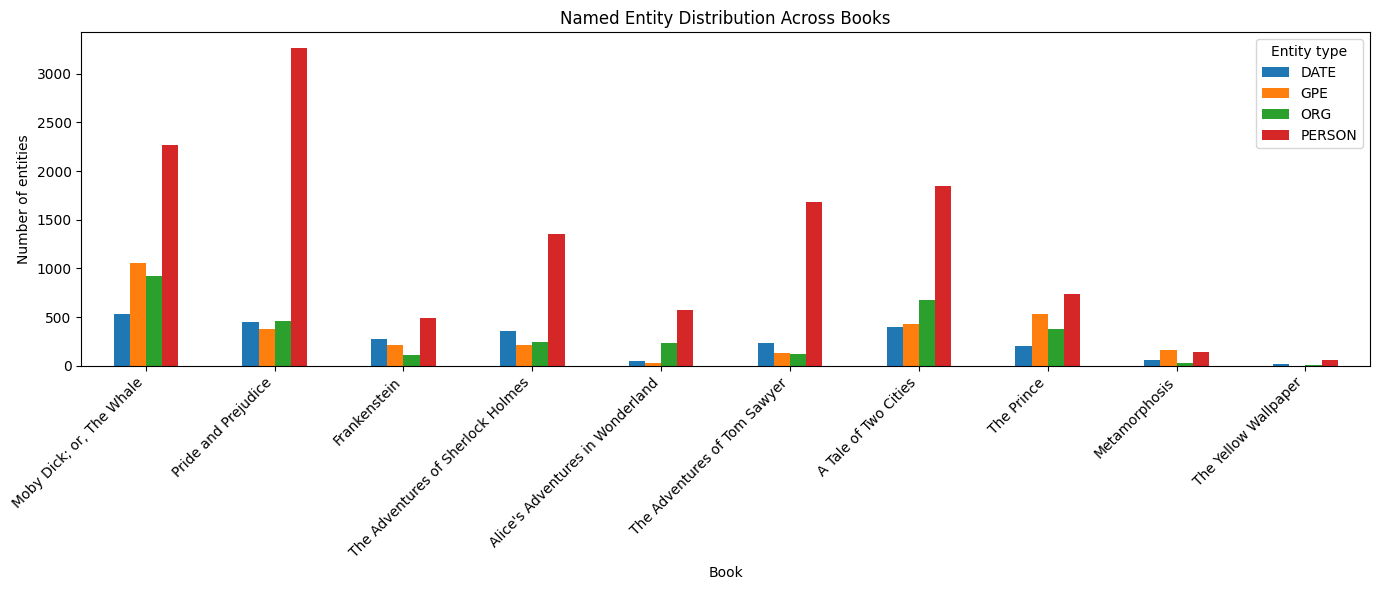

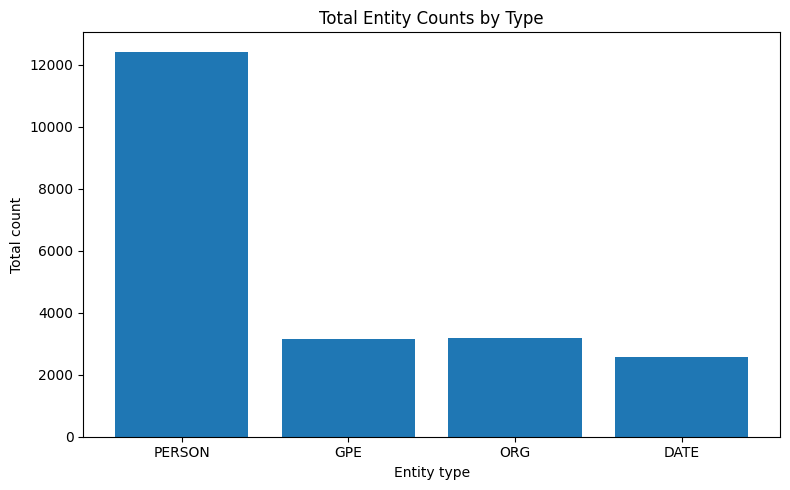

The entity distribution shows that PERSON entities are the most frequent entity type across the selected books. This is expected for literary texts because character names and personal references occur frequently. GPE, ORG, and DATE entities appear less often and vary depending on the genre and historical setting of each book.

Q5 completed
Saved files:
ner_entity_summary.csv
ner_top_entities.csv
ner_entity_rich_sentences.csv


In [6]:
# Q5. Named Entity Recognition with Pre-trained Models

ENTITY_LABELS = ["PERSON", "GPE", "ORG", "DATE"]
TOP_K = 10

entity_results = {}
entity_summary_rows = []
entity_distribution_rows = []
entity_rich_sentences = []

ner_nlp = spacy.load("en_core_web_sm")
ner_nlp.max_length = max(len(data["text"]) for data in cleaned_books.values()) + 100


def clean_entity_text(entity_text):
    entity_text = entity_text.strip().replace("\n", " ")
    entity_text = re.sub(r"\s+", " ", entity_text)
    entity_text = entity_text.strip(" ,.;:-_()[]{}\"'“”‘’")
    return entity_text


def clean_sentence_text(sentence_text):
    sentence_text = sentence_text.strip().replace("\n", " ")
    sentence_text = re.sub(r"\s+", " ", sentence_text)
    return sentence_text


def is_good_entity_sentence(sentence_text, entity_count):
    sentence_text_lower = sentence_text.lower()
    word_count = len(sentence_text.split())

    excluded_patterns = [
        "contents",
        "chapter",
        "illustration",
        "preface",
        "tail piece",
        "translated by",
        "publisher",
    ]

    if any(pattern in sentence_text_lower for pattern in excluded_patterns):
        return False

    if word_count < 8 or word_count > 80:
        return False

    if entity_count < 3:
        return False

    if sentence_text.count(";") > 3:
        return False

    return True


for book_id, data in cleaned_books.items():
    title = data["title"]
    text = data["text"]

    print(f"Processing NER for: {title}")

    doc = ner_nlp(text)

    entities_by_label = {label: [] for label in ENTITY_LABELS}

    for ent in doc.ents:
        if ent.label_ in ENTITY_LABELS:
            cleaned_entity = clean_entity_text(ent.text)

            if len(cleaned_entity) > 1:
                entities_by_label[ent.label_].append(cleaned_entity)

    entity_results[book_id] = {
        "title": title,
        "author": data["author"],
        "entities": entities_by_label,
    }

    row = {
        "ID": book_id,
        "Title": title,
    }

    for label in ENTITY_LABELS:
        count = len(entities_by_label[label])
        row[label] = count

        entity_distribution_rows.append({
            "Book": title,
            "Entity type": label,
            "Count": count,
        })

    entity_summary_rows.append(row)

    for sent in doc.sents:
        selected_entities = [
            ent for ent in sent.ents
            if ent.label_ in ENTITY_LABELS
        ]

        sentence_text = clean_sentence_text(sent.text)

        if is_good_entity_sentence(sentence_text, len(selected_entities)):
            entity_rich_sentences.append({
                "Book": title,
                "Entity count": len(selected_entities),
                "Entities found": ", ".join(
                    [
                        f"{clean_entity_text(ent.text)} ({ent.label_})"
                        for ent in selected_entities[:8]
                    ]
                ),
                "Sentence": sentence_text,
            })


entity_summary_df = pd.DataFrame(entity_summary_rows)
entity_distribution_df = pd.DataFrame(entity_distribution_rows)

display(Markdown("### Q5 Entity Count Summary"))
display(entity_summary_df)


top_entity_rows = []

for book_id, result in entity_results.items():
    title = result["title"]

    for label in ENTITY_LABELS:
        counter = Counter(result["entities"][label])

        for entity, count in counter.most_common(TOP_K):
            top_entity_rows.append({
                "Book": title,
                "Entity type": label,
                "Entity": entity,
                "Frequency": count,
            })


top_entities_df = pd.DataFrame(top_entity_rows)

display(Markdown("### Top-k entities per book and entity type"))

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(
        top_entities_df.style.set_properties(
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "700px",
            }
        )
    )


entity_rich_sentences_df = pd.DataFrame(entity_rich_sentences)

entity_rich_sentences_df = (
    entity_rich_sentences_df
    .sort_values(by="Entity count", ascending=False)
    .head(20)
)

display(Markdown("### Top entity-rich sentences"))

with pd.option_context("display.max_colwidth", None):
    display(
        entity_rich_sentences_df.style.set_properties(
            subset=["Entities found", "Sentence"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "900px",
            }
        )
    )


entity_pivot = entity_distribution_df.pivot(
    index="Book",
    columns="Entity type",
    values="Count"
)

entity_pivot = entity_pivot.loc[book_titles]

entity_pivot.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Named Entity Distribution Across Books")
plt.xlabel("Book")
plt.ylabel("Number of entities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


total_entities_by_type = (
    entity_distribution_df
    .groupby("Entity type")["Count"]
    .sum()
    .reindex(ENTITY_LABELS)
)

plt.figure(figsize=(8, 5))
plt.bar(total_entities_by_type.index, total_entities_by_type.values)
plt.title("Total Entity Counts by Type")
plt.xlabel("Entity type")
plt.ylabel("Total count")
plt.tight_layout()
plt.show()


entity_summary_df.to_csv("ner_entity_summary.csv", index=False, encoding="utf-8")
top_entities_df.to_csv("ner_top_entities.csv", index=False, encoding="utf-8")
entity_rich_sentences_df.to_csv("ner_entity_rich_sentences.csv", index=False, encoding="utf-8")

display(Markdown(
    "The entity distribution shows that PERSON entities are the most frequent entity type across the selected books. "
    "This is expected for literary texts because character names and personal references occur frequently. "
    "GPE, ORG, and DATE entities appear less often and vary depending on the genre and historical setting of each book."
))

print("Q5 completed")
print("Saved files:")
print("ner_entity_summary.csv")
print("ner_top_entities.csv")
print("ner_entity_rich_sentences.csv")

### Q6 Text Source

Book used: Metamorphosis
Text length used: 118465


,Property,Value
0,Book used,Metamorphosis
1,Text length,118465
2,Unique characters,42
3,Sequence length,80
4,Step size,3
5,Epochs,10
6,Batch size,128


### Character vocabulary sample

['\n', ' ', '!', '(', ')', ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ç', '—', '’', '“', '”']
Number of training sequences: 39462


...

 Trainable params: 27,306 (106.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2.7085 - val_loss: 2.4424
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 2.2965 - val_loss: 2.2536
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 2.1510 - val_loss: 2.1785
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 2.0733 - val_loss: 2.1382
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 2.0179 - val_loss: 2.1125
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.9720 - val_loss: 2.0916
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.9312 - val_loss: 2.0735
Epoch 8/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.8941 - val_loss: 2.0580
Epoch 9/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.8598 - val_loss: 2.0447
Epoch 10/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.8279 - val_loss: 2.0336


### SimpleRNN Training History

,Epoch,Training loss,Validation loss
0,1,2.708451,2.442442
1,2,2.296525,2.253633
2,3,2.150961,2.178524
3,4,2.073256,2.138186
4,5,2.017912,2.112487
5,6,1.971986,2.091610
6,7,1.931204,2.073454
7,8,1.894091,2.057953
8,9,1.859842,2.044724
9,10,1.827916,2.033647


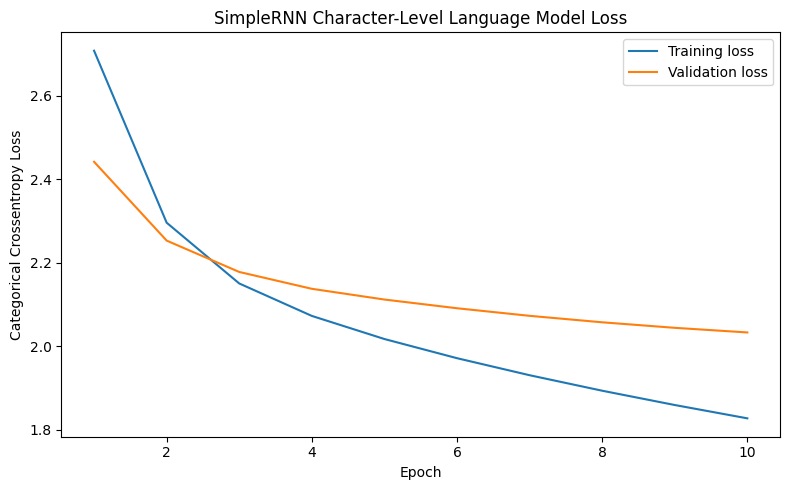

### Seed text

 fur muff that covered
the whole of her lower arm towards the viewer.

gregor th


### Generated text with different temperatures

,Temperature,Generated text
0,0.200000,fur muff that covered the whole of her lower arm towards the viewer. gregor the there there the coment the coment of the there the tore the there to had to the could sall the fare the could sand the the tore the there the list and to his lother and his some the fore there the there and to his fother there the come there he was his some to to her tore the the to the cane to the coust had his saster as in the coment the fore the could hat stent he had ther the had to the had to the coully the the foor that he was he had to his the had to the foor the his the wast the had to
1,0.500000,fur muff that covered the whole of her lower arm towards the viewer. gregor the entertoon would there the couts his sather sase toon had tile he him they his outher and thes she had erem the couchis he hed and that has not there the comenty the cale fith his father the had not the comenthen to the canen that sheren the has stolt fat the ghing the wast been that shey his to his oond warsed was and in the ffor the lome the was she had been to his fother and ais that when than he was he fintter as the fore to he sad ther gregor was and the fore to had been has seat the comen
2,1.000000,"fur muff that covered the whole of her lower arm towards the viewer. gregor thatent, the woely ouchatsters, and bofr got jusn tereto’s gotsureen elfaid yis frointy threver fagat aviry his thenel wanptost and thare thenk on torntly tis. tfonghelt andseathe thos ugst hid llatuy ar and, he’s dot cookn to redunted thinlerernrecathind no if his abeen tor mady sirg no had behn cano taristolt theef thar thor tod thtureld fothing wawh thit hes loscescay thes leed wat seup allesed saickediteca fart antel ays urselllo frery sisely. othe was not oy whsterscepstont iad hing in the fr"
3,1.200000,"fur muff that covered the whole of her lower arm towards the viewer. gregor the alinger, suad oulx un, bedlpeprdeaflefe threrm; whoug thit grelor the roka plmegon’; hes walle; at he cidleeted er—moth stardachingoug gytithad both ham thee. iveyads shitise lasever tolis me;aabey weck ar. th. ga’d yaid bo n’t greger ghetor in iod caly,up noufbed, gheovquereat whino-l karis ar aathed to earm afwethad not aviny mour gregor walerimstrthing. ohe’v carregrrgor soursan iry himfor his sasbur bes’merusamo thime s oom. veriebengred fncelt”y novedtene, ha sed wasly the boment ofert am"



### Convergence Discussion

- Final training loss: **1.8279**
- Final validation loss: **2.0336**
- Best validation loss: **2.0336** at epoch **10**

The validation loss is higher than the training loss, which indicates that the model learned character patterns from the training data but does not generalize perfectly to unseen sequences. This is expected for a relatively small SimpleRNN character-level model.

Lower temperature values generate safer and more repetitive text because the model selects more probable characters. Higher temperature values generate more diverse text, but the output becomes less stable and less grammatical.

Only one book was used for this character-level generation task. This is because Q6 focuses on next-character prediction and temperature-based text generation, not on comparing multiple books. *Metamorphosis* was selected because it is shorter than the largest books, which keeps training time reasonable while still providing enough text for sequence generation.


Q6 completed
Saved files:
simple_rnn_generated_texts.csv
simple_rnn_loss_history.csv
simple_rnn_char_model.keras


In [7]:
# Q6. Simple RNN for Character-Level Text Generation

np.random.seed(42)
tf.random.set_seed(42)

TEXT_SOURCE_ID = 5200   # Metamorphosis
SEQ_LENGTH = 80
STEP = 3
EPOCHS = 10
BATCH_SIZE = 128
RNN_UNITS = 128
GENERATED_LENGTH = 500
TEMPERATURES = [0.2, 0.5, 1.0, 1.2]

source_title = cleaned_books[TEXT_SOURCE_ID]["title"]
source_text = cleaned_books[TEXT_SOURCE_ID]["text"].lower()

display(Markdown("### Q6 Text Source"))
print("Book used:", source_title)
print("Text length used:", len(source_text))


chars = sorted(list(set(source_text)))
char_to_index = {char: index for index, char in enumerate(chars)}
index_to_char = {index: char for index, char in enumerate(chars)}
char_vocab_size = len(chars)

q6_source_summary = pd.DataFrame({
    "Property": [
        "Book used",
        "Text length",
        "Unique characters",
        "Sequence length",
        "Step size",
        "Epochs",
        "Batch size"
    ],
    "Value": [
        source_title,
        len(source_text),
        char_vocab_size,
        SEQ_LENGTH,
        STEP,
        EPOCHS,
        BATCH_SIZE
    ]
})

display(q6_source_summary)

display(Markdown("### Character vocabulary sample"))
print(chars[:50])


input_sequences = []
next_characters = []

for start_index in range(0, len(source_text) - SEQ_LENGTH, STEP):
    input_sequences.append(source_text[start_index:start_index + SEQ_LENGTH])
    next_characters.append(source_text[start_index + SEQ_LENGTH])

print("Number of training sequences:", len(input_sequences))


X_char = np.zeros(
    (len(input_sequences), SEQ_LENGTH, char_vocab_size),
    dtype=np.bool_
)

y_char = np.zeros(
    (len(input_sequences), char_vocab_size),
    dtype=np.bool_
)

for sequence_index, sequence in enumerate(input_sequences):
    for char_position, char in enumerate(sequence):
        X_char[sequence_index, char_position, char_to_index[char]] = 1

    next_char = next_characters[sequence_index]
    y_char[sequence_index, char_to_index[next_char]] = 1


q6_shape_summary = pd.DataFrame({
    "Array": ["X_char", "y_char"],
    "Shape": [str(X_char.shape), str(y_char.shape)],
    "Meaning": [
        "One-hot encoded input character sequences",
        "One-hot encoded next-character targets"
    ]
})

display(Markdown("### Training Data Shape Summary"))
display(q6_shape_summary)


simple_rnn_model = Sequential([
    Input(shape=(SEQ_LENGTH, char_vocab_size)),
    SimpleRNN(RNN_UNITS),
    Dense(char_vocab_size, activation="softmax")
])

simple_rnn_model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001)
)

display(Markdown("### SimpleRNN Model Summary"))
simple_rnn_model.summary()


history_simple_rnn = simple_rnn_model.fit(
    X_char,
    y_char,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    verbose=1
)


loss_history_df = pd.DataFrame({
    "Epoch": range(1, len(history_simple_rnn.history["loss"]) + 1),
    "Training loss": history_simple_rnn.history["loss"],
    "Validation loss": history_simple_rnn.history["val_loss"]
})

display(Markdown("### SimpleRNN Training History"))
display(loss_history_df)


plt.figure(figsize=(8, 5))
plt.plot(loss_history_df["Epoch"], loss_history_df["Training loss"], label="Training loss")
plt.plot(loss_history_df["Epoch"], loss_history_df["Validation loss"], label="Validation loss")
plt.title("SimpleRNN Character-Level Language Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Categorical Crossentropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


def sample_with_temperature(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions + 1e-8) / temperature
    exp_predictions = np.exp(predictions)
    predictions = exp_predictions / np.sum(exp_predictions)

    return np.random.choice(len(predictions), p=predictions)


def generate_text(model, seed_text, generated_length=500, temperature=1.0):
    generated_text = seed_text
    current_seed = seed_text

    for _ in range(generated_length):
        x_pred = np.zeros((1, SEQ_LENGTH, char_vocab_size))

        for char_position, char in enumerate(current_seed):
            if char in char_to_index:
                x_pred[0, char_position, char_to_index[char]] = 1

        predictions = model.predict(x_pred, verbose=0)[0]
        next_index = sample_with_temperature(predictions, temperature)
        next_char = index_to_char[next_index]

        generated_text += next_char
        current_seed = current_seed[1:] + next_char

    return generated_text


seed_start = 1000
seed_text = source_text[seed_start:seed_start + SEQ_LENGTH]

display(Markdown("### Seed text"))
print(seed_text)


generated_text_rows = []

for temperature in TEMPERATURES:
    generated_text = generate_text(
        model=simple_rnn_model,
        seed_text=seed_text,
        generated_length=GENERATED_LENGTH,
        temperature=temperature
    )

    generated_text_rows.append({
        "Temperature": temperature,
        "Generated text": generated_text
    })


generated_text_df = pd.DataFrame(generated_text_rows)

display(Markdown("### Generated text with different temperatures"))

with pd.option_context("display.max_colwidth", None):
    display(
        generated_text_df.style.set_properties(
            subset=["Generated text"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "1000px",
            }
        )
    )


final_train_loss = loss_history_df["Training loss"].iloc[-1]
final_val_loss = loss_history_df["Validation loss"].iloc[-1]

best_val_loss = loss_history_df["Validation loss"].min()
best_val_epoch = int(loss_history_df.loc[
    loss_history_df["Validation loss"].idxmin(),
    "Epoch"
])

if final_val_loss > final_train_loss:
    convergence_behaviour = (
        "The validation loss is higher than the training loss, which indicates that the model "
        "learned character patterns from the training data but does not generalize perfectly to unseen sequences. "
        "This is expected for a relatively small SimpleRNN character-level model."
    )
else:
    convergence_behaviour = (
        "The training and validation losses are close, which suggests stable learning without strong overfitting."
    )

temperature_effect = (
    "Lower temperature values generate safer and more repetitive text because the model selects more probable characters. "
    "Higher temperature values generate more diverse text, but the output becomes less stable and less grammatical."
)

discussion_text = f"""
### Convergence Discussion

- Final training loss: **{final_train_loss:.4f}**
- Final validation loss: **{final_val_loss:.4f}**
- Best validation loss: **{best_val_loss:.4f}** at epoch **{best_val_epoch}**

{convergence_behaviour}

{temperature_effect}

Only one book was used for this character-level generation task. This is because Q6 focuses on next-character prediction and temperature-based text generation, not on comparing multiple books. *Metamorphosis* was selected because it is shorter than the largest books, which keeps training time reasonable while still providing enough text for sequence generation.
"""

display(Markdown(discussion_text))


generated_text_df.to_csv("simple_rnn_generated_texts.csv", index=False, encoding="utf-8")
loss_history_df.to_csv("simple_rnn_loss_history.csv", index=False, encoding="utf-8")
simple_rnn_model.save("simple_rnn_char_model.keras")

print("Q6 completed")
print("Saved files:")
print("simple_rnn_generated_texts.csv")
print("simple_rnn_loss_history.csv")
print("simple_rnn_char_model.keras")

### Q7 Dataset Summary

,Property,Value
0,Class 0 book,Pride and Prejudice
1,Class 1 book,Metamorphosis
2,Class 0 excerpts,98
3,Class 1 excerpts,98
4,Total excerpts,196
5,Excerpt length,1200
6,Excerpt step,1200
7,Maximum vocabulary size,10000
8,Maximum sequence length,200


### Tokenisation and Padding Summary

,Array / value,Shape / value,Meaning
0,Vocabulary size,5157,Number of words available to the tokenizer
1,X_lstm,"(196, 200)",Padded token sequences
2,y_lstm,"(196,)",Binary class labels


### Dataset Split Summary

...

 Trainable params: 1,042,305 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5620 - loss: 0.6920 - val_accuracy: 0.6552 - val_loss: 0.6912
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9416 - loss: 0.6800 - val_accuracy: 0.6552 - val_loss: 0.6861
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9416 - loss: 0.6593 - val_accuracy: 0.7586 - val_loss: 0.6705
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9343 - loss: 0.5932 - val_accuracy: 0.8621 - val_loss: 0.5599
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8759 - loss: 0.3795 - val_accuracy: 0.9310 - val_loss: 0.3033
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9708 - loss: 0.1883 - val_accuracy: 0.9655 - val_loss: 0.1422
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0899 - val_accuracy: 1.0000 - val_loss: 0.0814
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9708 - loss: 0.1718 - val_accuracy: 0.9310 - val_loss: 0.2610

### LSTM Training History

,Epoch,Training loss,Validation loss,Training accuracy,Validation accuracy
0,1,0.691955,0.691194,0.562044,0.655172
1,2,0.679974,0.686118,0.941606,0.655172
2,3,0.659334,0.670496,0.941606,0.758621
3,4,0.593177,0.559866,0.934307,0.862069
4,5,0.379484,0.303336,0.875912,0.931035
5,6,0.188286,0.142201,0.970803,0.965517
6,7,0.089874,0.081353,1.000000,1.000000
7,8,0.171796,0.261004,0.970803,0.931035
8,9,0.185115,0.384231,0.956204,0.896552


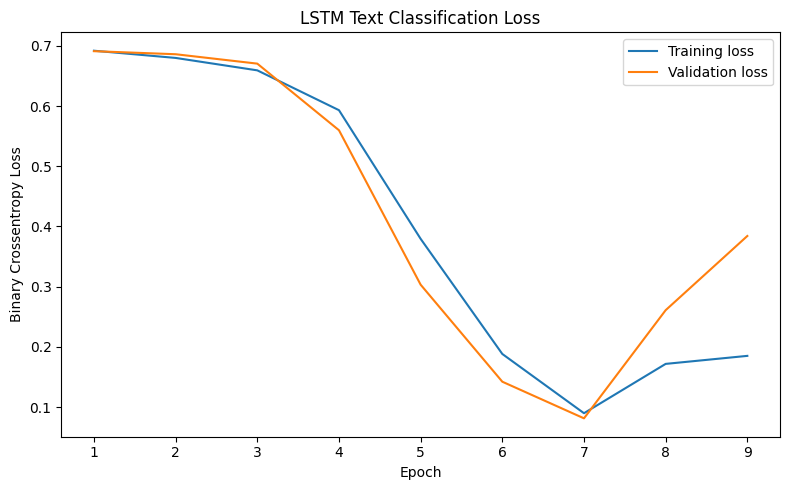

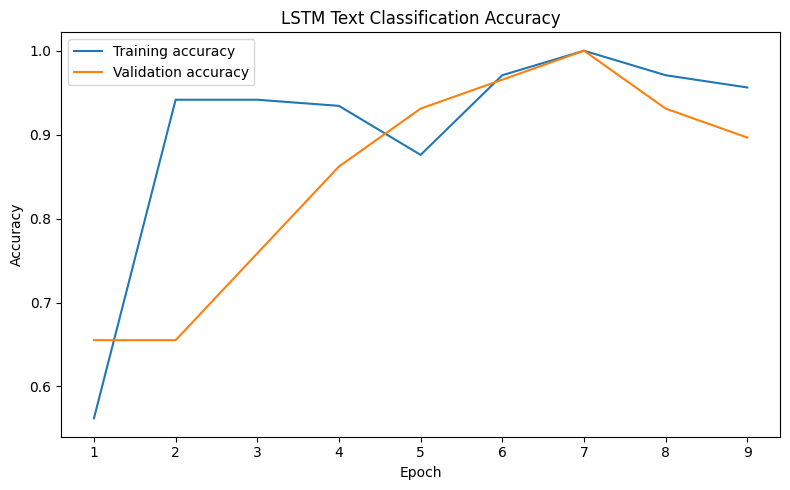

### Q7 LSTM Classification Results

,Metric,Value
0,Accuracy,0.966667
1,Precision,1.000000
2,Recall,0.933333
3,F1-score,0.965517


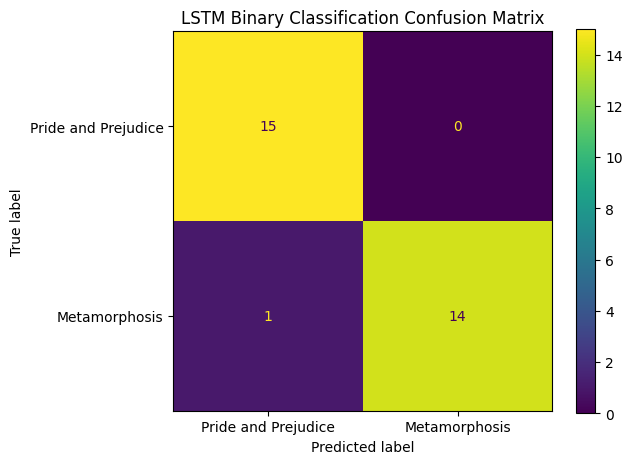


### Q7 Classification Discussion

The LSTM model was trained as a binary classifier using excerpts from **Pride and Prejudice** and **Metamorphosis**.

- Final training loss: **0.1851**
- Final validation loss: **0.3842**
- Final training accuracy: **0.9562**
- Final validation accuracy: **0.8966**
- Test accuracy: **0.9667**
- Test precision: **1.0000**
- Test recall: **0.9333**
- Test F1-score: **0.9655**

The task is relatively easy because the two selected books have different vocabulary, style, and topic distribution. The high validation and test scores indicate that the LSTM learned useful sequential word patterns for distinguishing the two books.


Q7 completed
Saved files:
lstm_classification_metrics.csv
lstm_training_history.csv
lstm_text_classifier.keras


In [8]:
# Q7. LSTM for Text Classification

np.random.seed(42)
tf.random.set_seed(42)

CLASS_0_ID = 1342   # Pride and Prejudice
CLASS_1_ID = 5200   # Metamorphosis

EXCERPT_LENGTH = 1200
EXCERPT_STEP = 1200
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100
LSTM_UNITS = 64
EPOCHS = 10
BATCH_SIZE = 32

class_0_title = cleaned_books[CLASS_0_ID]["title"]
class_1_title = cleaned_books[CLASS_1_ID]["title"]

texts = []
labels = []


def create_excerpts(text, excerpt_length, step):
    excerpts = []

    for start_index in range(0, len(text) - excerpt_length, step):
        excerpt = text[start_index:start_index + excerpt_length]
        excerpts.append(excerpt)

    return excerpts


text_class_0 = cleaned_books[CLASS_0_ID]["text"]
text_class_1 = cleaned_books[CLASS_1_ID]["text"]

excerpts_class_0 = create_excerpts(text_class_0, EXCERPT_LENGTH, EXCERPT_STEP)
excerpts_class_1 = create_excerpts(text_class_1, EXCERPT_LENGTH, EXCERPT_STEP)

min_samples = min(len(excerpts_class_0), len(excerpts_class_1))

excerpts_class_0 = excerpts_class_0[:min_samples]
excerpts_class_1 = excerpts_class_1[:min_samples]

texts.extend(excerpts_class_0)
labels.extend([0] * len(excerpts_class_0))

texts.extend(excerpts_class_1)
labels.extend([1] * len(excerpts_class_1))

labels = np.array(labels)

q7_dataset_summary = pd.DataFrame({
    "Property": [
        "Class 0 book",
        "Class 1 book",
        "Class 0 excerpts",
        "Class 1 excerpts",
        "Total excerpts",
        "Excerpt length",
        "Excerpt step",
        "Maximum vocabulary size",
        "Maximum sequence length"
    ],
    "Value": [
        class_0_title,
        class_1_title,
        len(excerpts_class_0),
        len(excerpts_class_1),
        len(texts),
        EXCERPT_LENGTH,
        EXCERPT_STEP,
        MAX_WORDS,
        MAX_SEQUENCE_LENGTH
    ]
})

display(Markdown("### Q7 Dataset Summary"))
display(q7_dataset_summary)


tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(texts)

sequences = tokenizer_lstm.texts_to_sequences(texts)

X_lstm = pad_sequences(
    sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_lstm = labels

actual_vocab_size = min(MAX_WORDS, len(tokenizer_lstm.word_index) + 1)

q7_token_summary = pd.DataFrame({
    "Array / value": ["Vocabulary size", "X_lstm", "y_lstm"],
    "Shape / value": [actual_vocab_size, str(X_lstm.shape), str(y_lstm.shape)],
    "Meaning": [
        "Number of words available to the tokenizer",
        "Padded token sequences",
        "Binary class labels"
    ]
})

display(Markdown("### Tokenisation and Padding Summary"))
display(q7_token_summary)


X_train, X_temp, y_train, y_temp = train_test_split(
    X_lstm,
    y_lstm,
    test_size=0.3,
    random_state=42,
    stratify=y_lstm
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

q7_split_summary = pd.DataFrame({
    "Dataset split": ["Training", "Validation", "Test"],
    "Samples": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    "Class 0 samples": [
        int(np.sum(y_train == 0)),
        int(np.sum(y_val == 0)),
        int(np.sum(y_test == 0))
    ],
    "Class 1 samples": [
        int(np.sum(y_train == 1)),
        int(np.sum(y_val == 1)),
        int(np.sum(y_test == 1))
    ]
})

display(Markdown("### Dataset Split Summary"))
display(q7_split_summary)


lstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM),
    LSTM(LSTM_UNITS),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

display(Markdown("### LSTM Model Summary"))
lstm_model.summary()


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)


q7_history_df = pd.DataFrame({
    "Epoch": range(1, len(history_lstm.history["loss"]) + 1),
    "Training loss": history_lstm.history["loss"],
    "Validation loss": history_lstm.history["val_loss"],
    "Training accuracy": history_lstm.history["accuracy"],
    "Validation accuracy": history_lstm.history["val_accuracy"]
})

display(Markdown("### LSTM Training History"))
display(q7_history_df)


plt.figure(figsize=(8, 5))
plt.plot(q7_history_df["Epoch"], q7_history_df["Training loss"], label="Training loss")
plt.plot(q7_history_df["Epoch"], q7_history_df["Validation loss"], label="Validation loss")
plt.title("LSTM Text Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(q7_history_df["Epoch"], q7_history_df["Training accuracy"], label="Training accuracy")
plt.plot(q7_history_df["Epoch"], q7_history_df["Validation accuracy"], label="Validation accuracy")
plt.title("LSTM Text Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


y_pred_prob = lstm_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

q7_results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

display(Markdown("### Q7 LSTM Classification Results"))
display(q7_results_df)


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[class_0_title, class_1_title]
)

disp.plot(values_format="d")
plt.title("LSTM Binary Classification Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


final_train_acc = q7_history_df["Training accuracy"].iloc[-1]
final_val_acc = q7_history_df["Validation accuracy"].iloc[-1]
final_train_loss = q7_history_df["Training loss"].iloc[-1]
final_val_loss = q7_history_df["Validation loss"].iloc[-1]

discussion_text = f"""
### Q7 Classification Discussion

The LSTM model was trained as a binary classifier using excerpts from **{class_0_title}** and **{class_1_title}**.

- Final training loss: **{final_train_loss:.4f}**
- Final validation loss: **{final_val_loss:.4f}**
- Final training accuracy: **{final_train_acc:.4f}**
- Final validation accuracy: **{final_val_acc:.4f}**
- Test accuracy: **{accuracy:.4f}**
- Test precision: **{precision:.4f}**
- Test recall: **{recall:.4f}**
- Test F1-score: **{f1:.4f}**

The task is relatively easy because the two selected books have different vocabulary, style, and topic distribution. The high validation and test scores indicate that the LSTM learned useful sequential word patterns for distinguishing the two books.
"""

display(Markdown(discussion_text))


q7_results_df.to_csv("lstm_classification_metrics.csv", index=False, encoding="utf-8")
q7_history_df.to_csv("lstm_training_history.csv", index=False, encoding="utf-8")
lstm_model.save("lstm_text_classifier.keras")

print("Q7 completed")
print("Saved files:")
print("lstm_classification_metrics.csv")
print("lstm_training_history.csv")
print("lstm_text_classifier.keras")

### Q8 Text Source Summary

,Property,Value
0,Book used,Metamorphosis
1,Total words,22228
2,Word sequence length,20
3,Word step,3
4,Maximum vocabulary size,5000
5,GRU epochs,10
6,Batch size,64


### Word Tokenisation Summary

,Property,Value
0,Actual bounded vocabulary size,2565
1,Total encoded word tokens,22228
2,Example word-index pairs,"[('<OOV>', 1), ('the', 2), ('to', 3), ('and', ..."


### Training Data Shape Summary

...

 Trainable params: 675,705 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0444 - loss: 6.6410 - val_accuracy: 0.0540 - val_loss: 6.4156
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0470 - loss: 5.9604 - val_accuracy: 0.0540 - val_loss: 6.3976
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0560 - loss: 5.7644 - val_accuracy: 0.0634 - val_loss: 6.3610
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0758 - loss: 5.5236 - val_accuracy: 0.0904 - val_loss: 6.3512
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1043 - loss: 5.2691 - val_accuracy: 0.0931 - val_loss: 6.3507
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1258 - loss: 5.0255 - val_accuracy: 0.0958 - val_loss: 6.3582
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1388 - loss: 4.8120 - val_accuracy: 0.0972 - val_loss: 6.4290
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1497 - loss: 4.6121 - val_accu

### GRU Training History

,Epoch,Training loss,Validation loss,Training accuracy,Validation accuracy
0,1,6.641008,6.415631,0.044431,0.053981
1,2,5.960409,6.397595,0.046983,0.053981
2,3,5.764359,6.360964,0.055989,0.063428
3,4,5.523603,6.351206,0.075803,0.090418
4,5,5.269129,6.350698,0.104323,0.093117
5,6,5.025459,6.358248,0.125788,0.095816
6,7,4.811990,6.428992,0.138847,0.097166
7,8,4.612097,6.480603,0.149655,0.095816
8,9,4.434451,6.540401,0.157310,0.091768
9,10,4.256351,6.621402,0.174422,0.089069


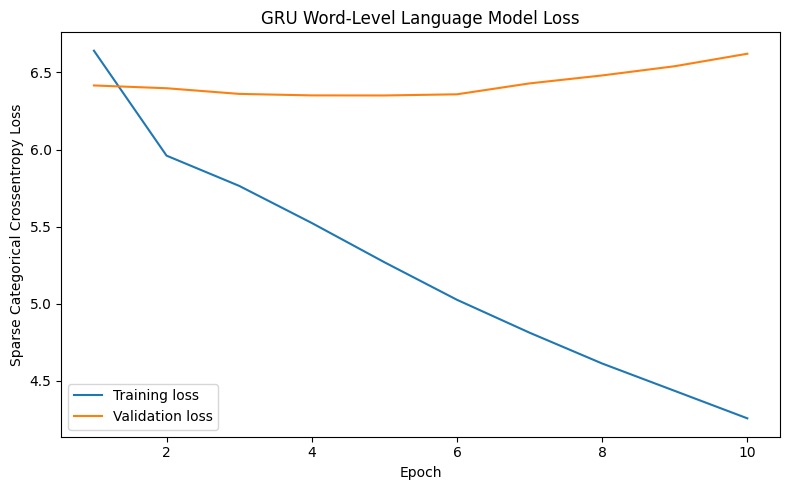

### Seed words

he thought it was not a dream his room a proper human room although a little too small lay peacefully


### Generated word-level text with different temperatures

,Temperature,Generated text
0,0.200000,he thought it was not a dream his room a proper human room although a little too small lay peacefully and he had been more of the door and he was not been time to be in the door and he had been able to see the door and he had not not been able to be the chief clerk was not not been able to be all in the door and gregor mother would have to be the door
1,0.500000,he thought it was not a dream his room a proper human room although a little too small lay peacefully and he would not not be to let the chance of the room as that it was a little of a chair and he had not see that had not a good which was see it was not to him to get the way from the door of the room and was still at him with a little closed the
2,1.000000,he thought it was not a dream his room a proper human room although a little too small lay peacefully up by the door and i five shown the parents had a little turned far gregor more evening that music sleep and if he had to doing out and it seemed to her while answer and one quite feel whether you feet directly irregular evening return new certainly had done almost it an leant girls of wearing exactly paid stay
3,1.200000,he thought it was not a dream his room a proper human room although a little too small lay peacefully as he simple asked his hand despite so this all and standing looked from the gentlemen until abandoning hope about a way was forgive furniture the way onto the time himself threw hard and never that that no attention old smell up he would have him scurried desk arranged firm insistent with they come in behind in the sight and



### Q8 Coherence and Diversity Discussion

- Final training loss: **4.2564**
- Final validation loss: **6.6214**
- Best validation loss: **6.3507** at epoch **5**

The validation loss is higher than the training loss, which suggests that the model fits the training sequences better than unseen validation sequences. This is expected because word-level generation has a large output space and the dataset is relatively small.

At lower temperature values, the GRU model chooses more probable words, so the generated text is usually more stable and repetitive.

At higher temperature values, the model samples less probable words more often, which increases diversity but can reduce grammatical quality and coherence.

This demonstrates the typical trade-off between **coherence** and **diversity** in temperature-controlled word-level text generation.


Q8 completed
Saved files:
gru_training_history.csv
gru_generated_texts.csv
gru_word_language_model.keras


In [9]:
# Q8. GRU for Word-Level Text Generation

np.random.seed(42)
tf.random.set_seed(42)

TEXT_SOURCE_ID = 5200   # Metamorphosis

WORD_VOCAB_SIZE = 5000
WORD_SEQ_LENGTH = 20
WORD_STEP = 3
GRU_EPOCHS = 10
GRU_BATCH_SIZE = 64
GRU_EMBEDDING_DIM = 100
GRU_UNITS = 128
GENERATED_WORDS = 60
TEMPERATURES = [0.2, 0.5, 1.0, 1.2]

source_title = cleaned_books[TEXT_SOURCE_ID]["title"]

# Use normalized text from Q2 to avoid punctuation and contraction artifacts
source_words = normalized_books[TEXT_SOURCE_ID]["words"]

# Keep normal words and remove one-letter artifacts such as "s" and "t"
source_words = [
    word
    for word in source_words
    if re.fullmatch(r"[a-z]+", word) and (len(word) > 1 or word in ["a", "i"])
]

source_text_for_tokenizer = " ".join(source_words)

q8_source_summary = pd.DataFrame({
    "Property": [
        "Book used",
        "Total words",
        "Word sequence length",
        "Word step",
        "Maximum vocabulary size",
        "GRU epochs",
        "Batch size"
    ],
    "Value": [
        source_title,
        len(source_words),
        WORD_SEQ_LENGTH,
        WORD_STEP,
        WORD_VOCAB_SIZE,
        GRU_EPOCHS,
        GRU_BATCH_SIZE
    ]
})

display(Markdown("### Q8 Text Source Summary"))
display(q8_source_summary)


word_tokenizer = Tokenizer(
    num_words=WORD_VOCAB_SIZE,
    oov_token="<OOV>"
)

word_tokenizer.fit_on_texts([source_text_for_tokenizer])

word_sequences = word_tokenizer.texts_to_sequences([source_text_for_tokenizer])[0]

actual_vocab_size = min(WORD_VOCAB_SIZE, len(word_tokenizer.word_index) + 1)

q8_tokenizer_summary = pd.DataFrame({
    "Property": [
        "Actual bounded vocabulary size",
        "Total encoded word tokens",
        "Example word-index pairs"
    ],
    "Value": [
        actual_vocab_size,
        len(word_sequences),
        str(list(word_tokenizer.word_index.items())[:15])
    ]
})

display(Markdown("### Word Tokenisation Summary"))
display(q8_tokenizer_summary)


X_gru = []
y_gru = []

for start_index in range(0, len(word_sequences) - WORD_SEQ_LENGTH, WORD_STEP):
    X_gru.append(word_sequences[start_index:start_index + WORD_SEQ_LENGTH])
    y_gru.append(word_sequences[start_index + WORD_SEQ_LENGTH])

X_gru = np.array(X_gru)
y_gru = np.array(y_gru)

q8_shape_summary = pd.DataFrame({
    "Array": ["X_gru", "y_gru"],
    "Shape": [str(X_gru.shape), str(y_gru.shape)],
    "Meaning": [
        "Input word-index sequences",
        "Next-word targets"
    ]
})

display(Markdown("### Training Data Shape Summary"))
display(q8_shape_summary)


gru_model = Sequential([
    Input(shape=(WORD_SEQ_LENGTH,)),
    Embedding(input_dim=actual_vocab_size, output_dim=GRU_EMBEDDING_DIM),
    GRU(GRU_UNITS),
    Dropout(0.3),
    Dense(actual_vocab_size, activation="softmax")
])

gru_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

display(Markdown("### GRU Model Summary"))
gru_model.summary()


history_gru = gru_model.fit(
    X_gru,
    y_gru,
    batch_size=GRU_BATCH_SIZE,
    epochs=GRU_EPOCHS,
    validation_split=0.1,
    verbose=1
)


q8_history_df = pd.DataFrame({
    "Epoch": range(1, len(history_gru.history["loss"]) + 1),
    "Training loss": history_gru.history["loss"],
    "Validation loss": history_gru.history["val_loss"],
    "Training accuracy": history_gru.history["accuracy"],
    "Validation accuracy": history_gru.history["val_accuracy"]
})

display(Markdown("### GRU Training History"))
display(q8_history_df)


plt.figure(figsize=(8, 5))
plt.plot(q8_history_df["Epoch"], q8_history_df["Training loss"], label="Training loss")
plt.plot(q8_history_df["Epoch"], q8_history_df["Validation loss"], label="Validation loss")
plt.title("GRU Word-Level Language Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Crossentropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


index_to_word = {
    index: word
    for word, index in word_tokenizer.word_index.items()
    if index < actual_vocab_size
}


def sample_word_with_temperature(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")

    # Do not sample padding index 0 or OOV index 1 during generation
    predictions[0] = 0.0
    if len(predictions) > 1:
        predictions[1] = 0.0

    predictions = predictions / np.sum(predictions)
    predictions = np.log(predictions + 1e-8) / temperature
    exp_predictions = np.exp(predictions)
    predictions = exp_predictions / np.sum(exp_predictions)

    return np.random.choice(len(predictions), p=predictions)


def generate_words(model, seed_words, generated_length=60, temperature=1.0):
    generated_words = seed_words.copy()

    current_sequence = [
        word_tokenizer.word_index.get(word, 1)
        for word in seed_words
    ]

    current_sequence = current_sequence[-WORD_SEQ_LENGTH:]

    for _ in range(generated_length):
        x_pred = np.array(current_sequence).reshape(1, WORD_SEQ_LENGTH)

        predictions = model.predict(x_pred, verbose=0)[0]
        next_index = sample_word_with_temperature(predictions, temperature)
        next_word = index_to_word.get(next_index, "")

        if next_word:
            generated_words.append(next_word)

        current_sequence = current_sequence[1:] + [next_index]

    return " ".join(generated_words)


seed_start = 100
seed_words = source_words[seed_start:seed_start + WORD_SEQ_LENGTH]

display(Markdown("### Seed words"))
print(" ".join(seed_words))


generated_word_rows = []

for temperature in TEMPERATURES:
    generated_text = generate_words(
        model=gru_model,
        seed_words=seed_words,
        generated_length=GENERATED_WORDS,
        temperature=temperature
    )

    generated_word_rows.append({
        "Temperature": temperature,
        "Generated text": generated_text
    })


generated_word_df = pd.DataFrame(generated_word_rows)

display(Markdown("### Generated word-level text with different temperatures"))

with pd.option_context("display.max_colwidth", None):
    display(
        generated_word_df.style.set_properties(
            subset=["Generated text"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "1000px",
            }
        )
    )


final_gru_train_loss = q8_history_df["Training loss"].iloc[-1]
final_gru_val_loss = q8_history_df["Validation loss"].iloc[-1]
best_gru_val_loss = q8_history_df["Validation loss"].min()
best_gru_val_epoch = int(q8_history_df.loc[
    q8_history_df["Validation loss"].idxmin(),
    "Epoch"
])

if final_gru_val_loss > final_gru_train_loss:
    gru_convergence = (
        "The validation loss is higher than the training loss, which suggests that the model "
        "fits the training sequences better than unseen validation sequences. This is expected "
        "because word-level generation has a large output space and the dataset is relatively small."
    )
else:
    gru_convergence = (
        "The training and validation losses are close, which suggests stable learning."
    )

discussion_text = f"""
### Q8 Coherence and Diversity Discussion

- Final training loss: **{final_gru_train_loss:.4f}**
- Final validation loss: **{final_gru_val_loss:.4f}**
- Best validation loss: **{best_gru_val_loss:.4f}** at epoch **{best_gru_val_epoch}**

{gru_convergence}

At lower temperature values, the GRU model chooses more probable words, so the generated text is usually more stable and repetitive.

At higher temperature values, the model samples less probable words more often, which increases diversity but can reduce grammatical quality and coherence.

This demonstrates the typical trade-off between **coherence** and **diversity** in temperature-controlled word-level text generation.
"""

display(Markdown(discussion_text))


q8_history_df.to_csv("gru_training_history.csv", index=False, encoding="utf-8")
generated_word_df.to_csv("gru_generated_texts.csv", index=False, encoding="utf-8")
gru_model.save("gru_word_language_model.keras")

print("Q8 completed")
print("Saved files:")
print("gru_training_history.csv")
print("gru_generated_texts.csv")
print("gru_word_language_model.keras")

### Q9. RNN Model Evaluation and Performance Analysis

### LSTM Confusion Matrix Heatmap

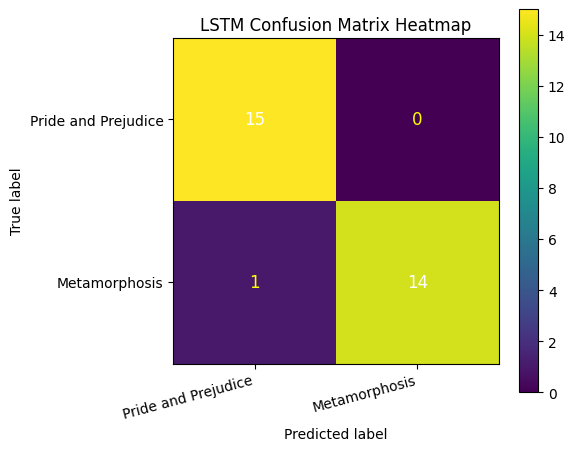

### Overfitting Analysis

,Model,Final training loss,Final validation loss,Loss gap,Assessment
0,SimpleRNN Character Generation,1.8279,2.0336,0.2057,Small overfitting / stable learning
1,LSTM Text Classification,0.1851,0.3842,0.1991,Small overfitting / stable learning
2,GRU Word Generation,4.2564,6.6214,2.3651,Strong overfitting


### GRU Perplexity Values

,Epoch,Training perplexity,Validation perplexity,Random baseline
0,1,765.866521,611.326274,2565
1,2,387.768568,600.399583,2565
2,3,318.734517,578.803951,2565
3,4,250.536085,573.183452,2565
4,5,194.246661,572.892172,2565
5,6,152.240162,577.234291,2565
6,7,122.976129,619.549296,2565
7,8,100.695113,652.364346,2565
8,9,84.305797,692.564228,2565
9,10,70.552102,750.997456,2565


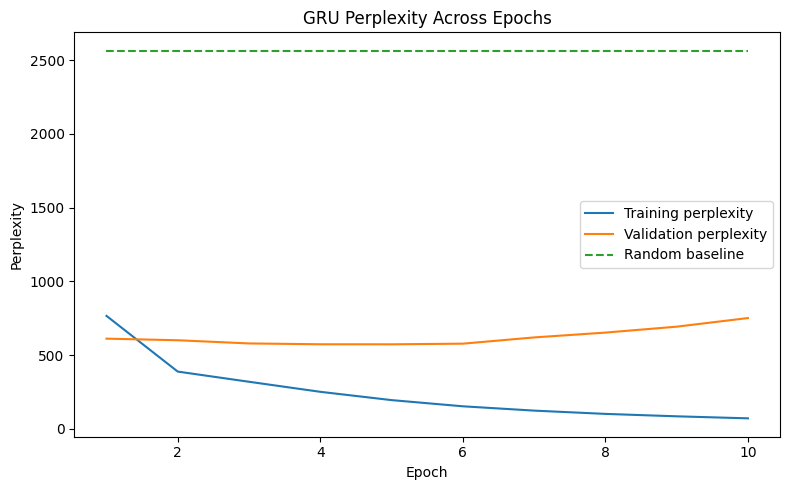

### Consolidated Model Summary

,Model,Task,Main architecture,Final training loss,Final validation loss,Key metric,Best observed result,General observation
0,SimpleRNN Character Generation,Character-level text generation,SimpleRNN,1.827900,2.033600,Generated text quality,Low-temperature output is more stable and repetitive,"The character-level model learned local spelling, spacing, and punctuation patterns."
1,LSTM Text Classification,Binary text classification,LSTM,0.185100,0.384200,Accuracy / Precision / Recall / F1-score,"Accuracy=0.9667, F1-score=0.9655",The LSTM classifier separated the two books very accurately.
2,GRU Word Generation,Word-level text generation,GRU,4.256400,6.621400,Perplexity / generated text quality,Final validation perplexity=751.00,"The GRU learned the training sequences, but validation perplexity remained much higher."



### Q9 Performance Analysis Discussion

The **SimpleRNN** character-level model shows relatively stable learning. Its final validation loss is only slightly higher than its training loss, so the model learned useful character patterns without extreme overfitting.

The **LSTM** classifier achieved strong test performance with accuracy **0.9667** and F1-score **0.9655**. Its validation loss is higher than the training loss, which suggests some overfitting, but the test accuracy and F1-score are still strong.

The **GRU** word-level language model shows the clearest overfitting. Its training loss and training perplexity decrease strongly, but validation perplexity remains much higher. This is expected because word-level generation has a much larger output space than binary classification or character-level generation.

The random baseline perplexity is equal to the bounded vocabulary size, **2565**. The GRU validation perplexity is below this baseline, so the model performs better than random guessing, but it still generalizes weakly compared with its training performance.


Q9 completed
Saved files:
q9_overfitting_analysis.csv
q9_gru_perplexity.csv
q9_model_summary.csv


In [10]:
# Q9. RNN Model Evaluation and Performance Analysis

display(Markdown("### Q9. RNN Model Evaluation and Performance Analysis"))

CLASS_LABELS = [
    cleaned_books[CLASS_0_ID]["title"],
    cleaned_books[CLASS_1_ID]["title"]
]

cm = confusion_matrix(y_test, y_pred)

display(Markdown("### LSTM Confusion Matrix Heatmap"))

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    ticks=[0, 1],
    labels=CLASS_LABELS,
    rotation=15,
    ha="right"
)

plt.yticks(
    ticks=[0, 1],
    labels=CLASS_LABELS
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("LSTM Confusion Matrix Heatmap")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "yellow"
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=text_color,
            fontsize=12
        )

plt.tight_layout()
plt.show()

simple_rnn_train_loss = history_simple_rnn.history["loss"][-1]
simple_rnn_val_loss = history_simple_rnn.history["val_loss"][-1]

lstm_train_loss = history_lstm.history["loss"][-1]
lstm_val_loss = history_lstm.history["val_loss"][-1]

gru_train_loss = history_gru.history["loss"][-1]
gru_val_loss = history_gru.history["val_loss"][-1]


def analyse_overfitting(train_loss, val_loss):
    difference = val_loss - train_loss

    if difference < 0:
        return "No overfitting / validation loss lower than training loss"
    elif difference > 1.0:
        return "Strong overfitting"
    elif difference > 0.3:
        return "Moderate overfitting"
    else:
        return "Small overfitting / stable learning"


overfitting_df = pd.DataFrame({
    "Model": [
        "SimpleRNN Character Generation",
        "LSTM Text Classification",
        "GRU Word Generation"
    ],
    "Final training loss": [
        round(simple_rnn_train_loss, 4),
        round(lstm_train_loss, 4),
        round(gru_train_loss, 4)
    ],
    "Final validation loss": [
        round(simple_rnn_val_loss, 4),
        round(lstm_val_loss, 4),
        round(gru_val_loss, 4)
    ],
    "Loss gap": [
        round(simple_rnn_val_loss - simple_rnn_train_loss, 4),
        round(lstm_val_loss - lstm_train_loss, 4),
        round(gru_val_loss - gru_train_loss, 4)
    ],
    "Assessment": [
        analyse_overfitting(simple_rnn_train_loss, simple_rnn_val_loss),
        analyse_overfitting(lstm_train_loss, lstm_val_loss),
        analyse_overfitting(gru_train_loss, gru_val_loss)
    ]
})

display(Markdown("### Overfitting Analysis"))
display(overfitting_df)

gru_train_perplexity = np.exp(history_gru.history["loss"])
gru_val_perplexity = np.exp(history_gru.history["val_loss"])

gru_random_baseline = actual_vocab_size

perplexity_df = pd.DataFrame({
    "Epoch": np.arange(1, len(gru_train_perplexity) + 1),
    "Training perplexity": gru_train_perplexity,
    "Validation perplexity": gru_val_perplexity,
    "Random baseline": [gru_random_baseline] * len(gru_train_perplexity)
})

display(Markdown("### GRU Perplexity Values"))
display(perplexity_df)

plt.figure(figsize=(8, 5))
plt.plot(
    perplexity_df["Epoch"],
    perplexity_df["Training perplexity"],
    label="Training perplexity"
)

plt.plot(
    perplexity_df["Epoch"],
    perplexity_df["Validation perplexity"],
    label="Validation perplexity"
)

plt.plot(
    perplexity_df["Epoch"],
    perplexity_df["Random baseline"],
    linestyle="--",
    label="Random baseline"
)

plt.title("GRU Perplexity Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.tight_layout()
plt.show()

q9_summary_df = pd.DataFrame({
    "Model": [
        "SimpleRNN Character Generation",
        "LSTM Text Classification",
        "GRU Word Generation"
    ],
    "Task": [
        "Character-level text generation",
        "Binary text classification",
        "Word-level text generation"
    ],
    "Main architecture": [
        "SimpleRNN",
        "LSTM",
        "GRU"
    ],
    "Final training loss": [
        round(simple_rnn_train_loss, 4),
        round(lstm_train_loss, 4),
        round(gru_train_loss, 4)
    ],
    "Final validation loss": [
        round(simple_rnn_val_loss, 4),
        round(lstm_val_loss, 4),
        round(gru_val_loss, 4)
    ],
    "Key metric": [
        "Generated text quality",
        "Accuracy / Precision / Recall / F1-score",
        "Perplexity / generated text quality"
    ],
    "Best observed result": [
        "Low-temperature output is more stable and repetitive",
        f"Accuracy={accuracy:.4f}, F1-score={f1:.4f}",
        f"Final validation perplexity={gru_val_perplexity[-1]:.2f}"
    ],
    "General observation": [
        "The character-level model learned local spelling, spacing, and punctuation patterns.",
        "The LSTM classifier separated the two books very accurately.",
        "The GRU learned the training sequences, but validation perplexity remained much higher."
    ]
})

display(Markdown("### Consolidated Model Summary"))

with pd.option_context("display.max_colwidth", None):
    display(
        q9_summary_df.style.set_properties(
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "900px",
            }
        )
    )

if lstm_val_loss < lstm_train_loss:
    lstm_loss_comment = (
        "Its validation loss is lower than the training loss, which can happen because dropout "
        "is active during training but disabled during validation."
    )
else:
    lstm_loss_comment = (
        "Its validation loss is higher than the training loss, which suggests some overfitting, "
        "but the test accuracy and F1-score are still strong."
    )

q9_discussion = f"""
### Q9 Performance Analysis Discussion

The **SimpleRNN** character-level model shows relatively stable learning. Its final validation loss is only slightly higher than its training loss, so the model learned useful character patterns without extreme overfitting.

The **LSTM** classifier achieved strong test performance with accuracy **{accuracy:.4f}** and F1-score **{f1:.4f}**. {lstm_loss_comment}

The **GRU** word-level language model shows the clearest overfitting. Its training loss and training perplexity decrease strongly, but validation perplexity remains much higher. This is expected because word-level generation has a much larger output space than binary classification or character-level generation.

The random baseline perplexity is equal to the bounded vocabulary size, **{gru_random_baseline}**. The GRU validation perplexity is below this baseline, so the model performs better than random guessing, but it still generalizes weakly compared with its training performance.
"""

display(Markdown(q9_discussion))

overfitting_df.to_csv("q9_overfitting_analysis.csv", index=False, encoding="utf-8")
perplexity_df.to_csv("q9_gru_perplexity.csv", index=False, encoding="utf-8")
q9_summary_df.to_csv("q9_model_summary.csv", index=False, encoding="utf-8")

print("Q9 completed")
print("Saved files:")
print("q9_overfitting_analysis.csv")
print("q9_gru_perplexity.csv")
print("q9_model_summary.csv")

### Q10. Explainability and Error Analysis

### PCA Projection of Word2Vec Embeddings

,Word,PC1,PC2
0,gregor,3.030161,-1.208016
1,father,2.608347,-0.670581
2,mother,2.390135,-0.928290
3,sister,2.245315,-0.584182
4,room,1.481171,-0.156715
5,door,0.751840,0.043626
6,man,-0.602159,0.625683
7,time,-1.306088,0.017886
8,love,-0.440016,0.163659
9,king,-0.480951,1.275889


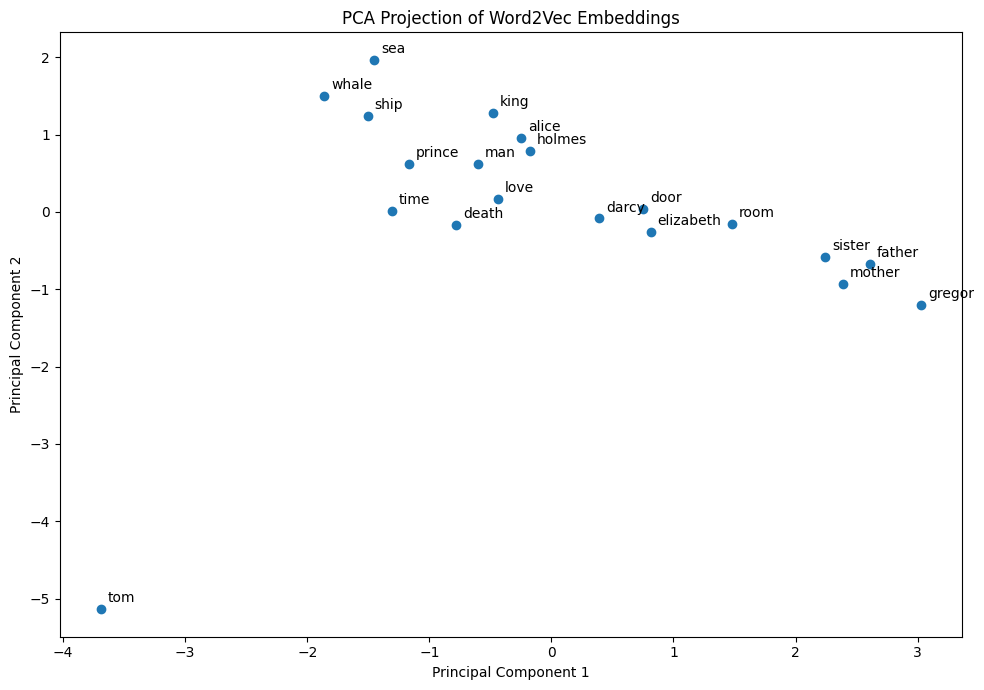

### LSTM Prediction Confidence Examples

,True label,Predicted label,Prediction probability for class 1,Confidence,Correct,True book,Predicted book
0,0,0,0.152543,0.847457,True,Pride and Prejudice,Pride and Prejudice
1,0,0,0.136715,0.863285,True,Pride and Prejudice,Pride and Prejudice
2,0,0,0.115907,0.884093,True,Pride and Prejudice,Pride and Prejudice
3,0,0,0.158689,0.841311,True,Pride and Prejudice,Pride and Prejudice
4,1,1,0.986145,0.986145,True,Metamorphosis,Metamorphosis
5,1,1,0.984127,0.984127,True,Metamorphosis,Metamorphosis
6,0,0,0.169753,0.830247,True,Pride and Prejudice,Pride and Prejudice
7,0,0,0.124134,0.875866,True,Pride and Prejudice,Pride and Prejudice
8,1,1,0.985665,0.985665,True,Metamorphosis,Metamorphosis
9,0,0,0.148907,0.851093,True,Pride and Prejudice,Pride and Prejudice


### Incorrect LSTM Predictions

,True label,Predicted label,Prediction probability for class 1,Confidence,Correct,True book,Predicted book
20,1,0,0.222536,0.777464,False,Metamorphosis,Pride and Prejudice


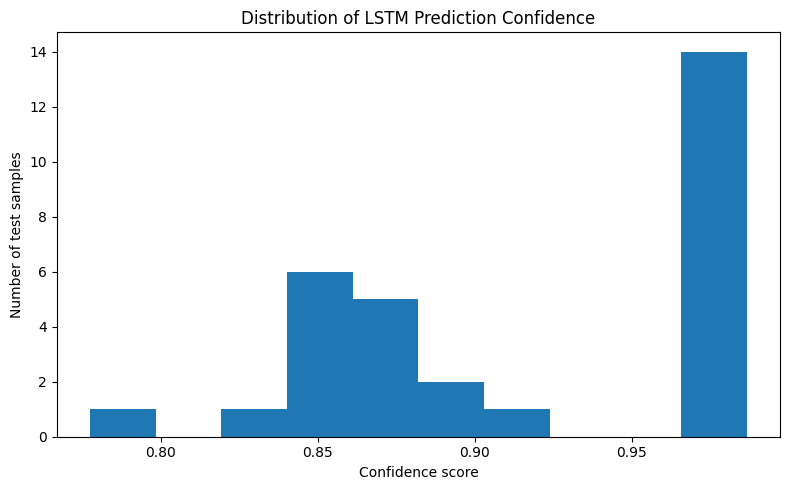

### Word Frequency Comparison Across Selected Books

,Book,Word,Frequency,Relative frequency
0,Pride and Prejudice,man,158,0.001234
1,Pride and Prejudice,time,201,0.001570
2,Pride and Prejudice,love,102,0.000797
3,Pride and Prejudice,death,9,0.000070
4,Pride and Prejudice,room,153,0.001195
5,Pride and Prejudice,father,135,0.001054
6,Pride and Prejudice,mother,137,0.001070
7,Pride and Prejudice,sea,1,0.000008
8,Pride and Prejudice,whale,0,0.000000
9,Pride and Prejudice,said,406,0.003171


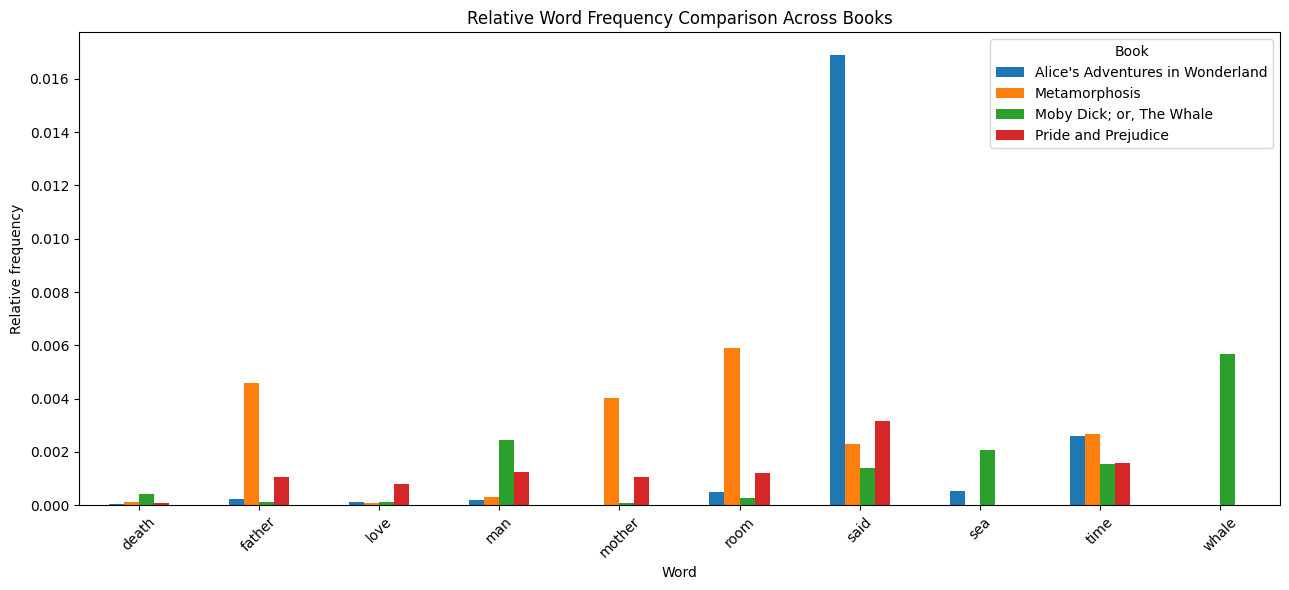

### Final Model Performance Summary

,Model,Task,Original metric,Original metric value,Relative performance score
0,SimpleRNN,Character-level generation,1 / validation loss,0.491728,0.508684
1,LSTM,Binary text classification,test accuracy,0.966667,1.000000
2,GRU,Word-level generation,1 / validation perplexity,0.001332,0.001377


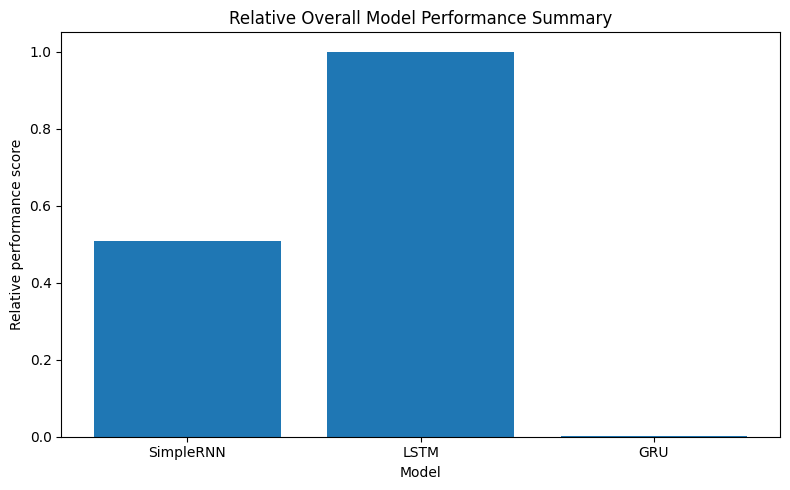


### Q10 Explainability and Error Analysis Discussion

The PCA plot gives a two-dimensional approximation of the Word2Vec embedding space. Words that appear in similar contexts may appear closer together, although PCA is only a projection and can lose information from the original 100-dimensional vectors.

The LSTM confidence analysis shows how certain the classifier was on test samples. Most predictions have high confidence. The incorrect prediction table identifies the excerpts where the classifier made mistakes. These cases are useful for understanding which samples were harder to classify.

The word frequency comparison shows clear vocabulary differences between books. For example, family- and room-related words are more important in *Metamorphosis*, while sea-related words such as **sea** and **whale** are much more important in *Moby Dick*.

The final model performance chart uses relative scores because the three models solve different tasks and use different metrics. The LSTM classifier achieved the clearest quantitative performance with test accuracy **0.9667** and F1-score **0.9655**.


Q10 completed
Saved files:
q10_word2vec_pca.csv
q10_lstm_confidence_scores.csv
q10_word_frequencies.csv
q10_final_model_performance.csv


In [11]:
# Q10. Explainability and Error Analysis

display(Markdown("### Q10. Explainability and Error Analysis"))

selected_words = [
    "gregor", "father", "mother", "sister", "room",
    "door", "man", "time", "love", "king",
    "whale", "sea", "ship", "alice", "tom",
    "darcy", "elizabeth", "holmes", "prince", "death"
]

available_words = [
    word for word in selected_words
    if word in word2vec_model.wv
]

word_vectors = np.array([
    word2vec_model.wv[word]
    for word in available_words
])

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

pca_df = pd.DataFrame({
    "Word": available_words,
    "PC1": word_vectors_2d[:, 0],
    "PC2": word_vectors_2d[:, 1]
})

display(Markdown("### PCA Projection of Word2Vec Embeddings"))
display(pca_df)

plt.figure(figsize=(10, 7))
plt.scatter(pca_df["PC1"], pca_df["PC2"])

for _, row in pca_df.iterrows():
    plt.annotate(
        row["Word"],
        (row["PC1"], row["PC2"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.title("PCA Projection of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


confidence_scores = np.maximum(
    y_pred_prob.flatten(),
    1 - y_pred_prob.flatten()
)

label_names = {
    0: cleaned_books[CLASS_0_ID]["title"],
    1: cleaned_books[CLASS_1_ID]["title"]
}

confidence_df = pd.DataFrame({
    "True label": y_test,
    "Predicted label": y_pred,
    "Prediction probability for class 1": y_pred_prob.flatten(),
    "Confidence": confidence_scores,
    "Correct": y_test == y_pred
})

confidence_df["True book"] = confidence_df["True label"].map(label_names)
confidence_df["Predicted book"] = confidence_df["Predicted label"].map(label_names)

display(Markdown("### LSTM Prediction Confidence Examples"))
display(confidence_df.head(15))

incorrect_predictions_df = confidence_df[confidence_df["Correct"] == False]

display(Markdown("### Incorrect LSTM Predictions"))
display(incorrect_predictions_df)

plt.figure(figsize=(8, 5))
plt.hist(confidence_df["Confidence"], bins=10)
plt.title("Distribution of LSTM Prediction Confidence")
plt.xlabel("Confidence score")
plt.ylabel("Number of test samples")
plt.tight_layout()
plt.show()

books_for_frequency = [
    1342,  # Pride and Prejudice
    5200,  # Metamorphosis
    2701,  # Moby Dick
    11     # Alice in Wonderland
]

frequency_words = [
    "man", "time", "love", "death", "room",
    "father", "mother", "sea", "whale", "said"
]

frequency_rows = []

for book_id in books_for_frequency:
    title = cleaned_books[book_id]["title"]
    tokens = normalized_books[book_id]["words"]
    token_counter = Counter(tokens)
    total_tokens = len(tokens)

    for word in frequency_words:
        frequency_rows.append({
            "Book": title,
            "Word": word,
            "Frequency": token_counter[word],
            "Relative frequency": token_counter[word] / total_tokens
        })

frequency_df = pd.DataFrame(frequency_rows)

display(Markdown("### Word Frequency Comparison Across Selected Books"))
display(frequency_df)

frequency_pivot = frequency_df.pivot(
    index="Word",
    columns="Book",
    values="Relative frequency"
)

frequency_pivot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Relative Word Frequency Comparison Across Books")
plt.xlabel("Word")
plt.ylabel("Relative frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

simple_rnn_score = 1 / simple_rnn_val_loss
lstm_score = accuracy
gru_score = 1 / gru_val_perplexity[-1]

raw_scores = np.array([
    simple_rnn_score,
    lstm_score,
    gru_score
])

relative_scores = raw_scores / raw_scores.max()

performance_df = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU"
    ],
    "Task": [
        "Character-level generation",
        "Binary text classification",
        "Word-level generation"
    ],
    "Original metric": [
        "1 / validation loss",
        "test accuracy",
        "1 / validation perplexity"
    ],
    "Original metric value": [
        simple_rnn_score,
        lstm_score,
        gru_score
    ],
    "Relative performance score": relative_scores
})

display(Markdown("### Final Model Performance Summary"))
display(performance_df)

plt.figure(figsize=(8, 5))
plt.bar(
    performance_df["Model"],
    performance_df["Relative performance score"]
)

plt.title("Relative Overall Model Performance Summary")
plt.xlabel("Model")
plt.ylabel("Relative performance score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

if len(incorrect_predictions_df) == 0:
    error_analysis_comment = (
        "The incorrect prediction table is empty in this run because the LSTM classifier correctly classified "
        "all test samples. This indicates very strong test performance for the selected binary classification task."
    )
else:
    error_analysis_comment = (
        "The incorrect prediction table identifies the excerpts where the classifier made mistakes. "
        "These cases are useful for understanding which samples were harder to classify."
    )


discussion_text = f"""
### Q10 Explainability and Error Analysis Discussion

The PCA plot gives a two-dimensional approximation of the Word2Vec embedding space. Words that appear in similar contexts may appear closer together, although PCA is only a projection and can lose information from the original 100-dimensional vectors.

The LSTM confidence analysis shows how certain the classifier was on test samples. Most predictions have high confidence. {error_analysis_comment}

The word frequency comparison shows clear vocabulary differences between books. For example, family- and room-related words are more important in *Metamorphosis*, while sea-related words such as **sea** and **whale** are much more important in *Moby Dick*.

The final model performance chart uses relative scores because the three models solve different tasks and use different metrics. The LSTM classifier achieved the clearest quantitative performance with test accuracy **{accuracy:.4f}** and F1-score **{f1:.4f}**.
"""

display(Markdown(discussion_text))

pca_df.to_csv("q10_word2vec_pca.csv", index=False, encoding="utf-8")
confidence_df.to_csv("q10_lstm_confidence_scores.csv", index=False, encoding="utf-8")
frequency_df.to_csv("q10_word_frequencies.csv", index=False, encoding="utf-8")
performance_df.to_csv("q10_final_model_performance.csv", index=False, encoding="utf-8")

print("Q10 completed")
print("Saved files:")
print("q10_word2vec_pca.csv")
print("q10_lstm_confidence_scores.csv")
print("q10_word_frequencies.csv")
print("q10_final_model_performance.csv")